In [24]:
# using Pkg

# Pkg.build("PyCall")

In [1]:
# loading modules
using PyPlot, Printf, LinearAlgebra, FFTW, FileIO, JLD2

using CUDA

using Setfield

# include("../../LinStab/mjcl_stab.jl")
# using .LinStab

using FourierFlows: CPU, TwoDGrid, plan_flows_rfft

using GeophysicalFlows

using Glob

using Statistics

using Parameters

using StaticArrays, KernelAbstractions

run_file_dir = "/scratch/cimes/ml1994/QG/julia/QG_topo/"
include(run_file_dir * "mjcl_gfjl_fcns.jl")


update_two_layer_omega_diags (generic function with 2 methods)

In [2]:
# matplotlib[:rc]("text", usetex= "true")
# matplotlib[:rc]("text.latex", preamble= "\\usepackage{amsmath,amsthm}")

# using PlotUtils



# Defining model parameters

In [3]:

dev = GeophysicalFlows.CPU()

Ny = Nx = n = 1024                # 2D resolution = n²


###################################################################################
## Geometry and background fields
###################################################################################

Nz = nlayers = 2                 # number of layers
f0 = f₀= 8.3e-5            # Coriolis param [s^-1]
g = 9.81                    # gravity
H = [2000., 2000.]     # the rest depths of each layer;

Us = [0.01, 0.017634058790440166, 0.024]
rhos = 1025.75 - 0.5775

kt = 0.

rho0 = 1025.        # Boussinesq reference density

# always zero for now, model can't even take this in as a parameter...
V = zeros(nlayers)


# running model

rho = ρ = [0., 1025.75]
rho[1] = ρ[1] = rhos[1]

strat_str = "uni_strat"
shear_str = "uni_shear"

# change U here
U = [0.,0.]
U[1] = Us[1]

gprime = (g/rho0)*(ρ[2] - ρ[1])

Ld = sqrt(gprime * sum(H)) / 2 / f0

L = Lx = Ly = 25*2*pi*Ld   # domain size [m]

###################################################################################
## Planetary PV gradient
###################################################################################
betas = βs = collect(range(-1.5,1.5,13)) * (U[1]/2) * Ld^-2
β = 0. # 1e-11              # the y-gradient of planetary PV; beta = β = 0. * (U[1]/2) * Ld^-2

###################################################################################
## Topography
###################################################################################

# set topography w/ current options:
topo_type = "y_slope"

# Defining a bulk slope parameter...should probably change this!

# setting slope(s)
S32 = f0 * U[1] / gprime

dyetab_over_S32 = collect(range(-1.5,1.5,13))
h0s = dyetab_over_S32 .* S32
# h0s = h0s[7:end]

# tuple of (bottom slope, h_rms)
h0 = (h0s[1], 0.)    #

# central wavenumber for rough topo
kt = 0.

# defining GFJL topo params
interim_params = mod_params(topo_type=topo_type, h0=h0, kt=kt)

topographic_pv_gradient, eta = define_topo(interim_params)

###################################################################################
# Dissipation
###################################################################################

# biharmonic viscosity
nν = 4
νstar = 0. # 10^-13
ν = νstar * ((U[1]-U[end])/2) * (Lx/2/pi)^7

dyn_nu = false

# Linear bottom drag
μstars = [0.125, 0.25, 0.5, 1.0, 2.0, 4.0]
mus = @. μstars * ((U[1]-U[end]) / 2) / Ld

# Quadratic bottom drag
κstars = [0.]
kappas = [0.] # @. κstars / Ld

###################################################################################
## Time stepping and sample rate
###################################################################################

if ν==0.
    stepper = "FilteredETDRK4"
    # af = 0.
    # global filt_order=4
    # global innerK = 2/3
else
    stepper = "ETDRK4"
    # af = 1/3
    # global filt_order=4
    # innerK = 2/3
end

# should I set dt via CFL condition instead?
dt = 600.

###################################################################################
## Details of saving data
###################################################################################
global diags = diag_bools(two_layer_kspace_modal_nrg_budget_bool=true);

# where to save model output; frequency of output
# data_dir = "/scratch/cimes/ml1994/QG/julia/data/sloping_LD_two_layer_data/"

data_dir = "/scratch/cimes/ml1994/QG/julia/data/JFM_May2025_data/"

f_s = 5. * (Ld / ((U[1]-U[end])/2)) #  N eddy turnover periods

# sampling period in time steps (set above)
nsubs = round(Int64, f_s/dt)

###################################################################################
## Model run parameters
###################################################################################

# steady-state  parameters
ss_yr_max = ceil(100 * (Ld / ((U[1]-U[end])/2)) / 3600 / 24 / 365.25)  # number of eddy periods converted to years for model run
yr_increment = 1.0 # how often to write to a save file

restart_bool = false

pre_buoy_restart_file = true
data_dir_pre_buoy = "/scratch/cimes/ml1994/QG/julia/data/two_layer_drag_study/"

###################################################################################
## Define params struct
###################################################################################
global model_params = mod_params(
data_dir = data_dir,
Nz = Nz, Nx = Nx, Ny = Ny, Lx = Lx, Ly = Ly, Ld = Ld,
H = H,
rho0 = rho0, rho = rho, strat_str = strat_str,
shear_str = shear_str, U = U,
μ = mus[1], κ = kappas[1], nν = nν, ν = ν, dyn_nu = dyn_nu,
eta = eta, topographic_pv_gradient = topographic_pv_gradient, topo_type = topo_type, h0 = h0,
β = β,
dt = dt,
stepper = stepper,
dev = dev,
restart_bool = restart_bool,
pre_buoy_restart_file = pre_buoy_restart_file,
data_dir_pre_buoy = data_dir_pre_buoy,
ss_yr_max = ss_yr_max,
yr_increment = yr_increment,
nsubs = nsubs)

###################################################################################
## Initialize model
###################################################################################

prob, prob_filt = initialize_model(model_params);

# prob = set_initial_conditions(prob, prob_filt, model_params)

sol, clock, params, vars, grid = prob.sol, prob.clock, prob.params, prob.vars, prob.grid;




In [4]:
dev = grid.device
T = eltype(grid)
A = device_array(dev)

rfftplan = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, 1), [1, 2]; flags=FFTW.MEASURE);


In [5]:
function redef_mu_kappa(model_params, mu, kappa)
    @unpack_mod_params model_params

    mp_out = mod_params(
    data_dir = data_dir,
    Nz = Nz, Nx = Nx, Ny = Ny, Lx = Lx, Ly = Ly, Ld = Ld,
    H = H,
    rho0 = rho0, rho = rho, strat_str = strat_str,
    shear_str = shear_str, U = U,
    μ = mu , κ = kappa , nν = nν, ν = ν, dyn_nu=dyn_nu,
    eta = eta, topographic_pv_gradient = topographic_pv_gradient, topo_type = topo_type, h0 = h0,
    β = β,
    dt = dt,
    stepper = stepper,
    dev = dev,
    restart_bool = restart_bool,
    ss_yr_max = ss_yr_max,
    yr_increment = yr_increment,
    nsubs = nsubs);

    return mp_out
end

redef_mu_kappa (generic function with 1 method)

In [6]:
using PlotUtils

cm = cgrad(:coolwarm);
clrs = [cm[i] for i in range(0,1,100)]

hc_range = collect(range(h0s[1],h0s[end],100))

function h_color(h_in,hc_range,colors)
    c_ind = argmin(abs.(h_in .- (hc_range)))

    color_out = [red(clrs[c_ind]),green(clrs[c_ind]),blue(clrs[c_ind])]

    if h_in==0
        color_out = [0.,0.,0.]
    end
    return color_out
end

####################################################################
## 
####################################################################

function plot_info_box(ax, var, x, y, plus_mode, fsize)
    textstr = var * "\n" * L"+ \rightarrow" * plus_mode

    # these are matplotlib.patch.Patch properties
    props = Dict("boxstyle"=>"round", "facecolor"=>"wheat", "alpha"=>0.5)
    
    # place a text box in upper left in axes coords
    ax.text(x, y, textstr, transform=ax.transAxes, fontsize=fsize,
            ha="left", va="top", bbox=props)

    return nothing
end


####################################################################
## 
####################################################################


# tab20_range = collect(range(0,1,20))

function tab20_color(c_ind)

    cm2 = cgrad(:tab20);
    clrs2 = [cm2[i] for i in range(0,1,20)]

    color_out = [red(clrs2[c_ind]),green(clrs2[c_ind]),blue(clrs2[c_ind])]

    return color_out
end



tab20_color (generic function with 1 method)

In [8]:
a["jld_data"]

Dict{String, Any} with 17 entries:
  "f0"                      => 8.3e-5
  "nu"                      => 0.0
  "Nz"                      => 2
  "Qy"                      => [-2.45521e-27, -1.2464e-11]
  "dt"                      => 500.0
  "L"                       => 4.44929e6
  "topographic_pv_gradient" => (0.0, 0.0)
  "eta"                     => nothing
  "mu"                      => 2.20653e-8
  "stepper"                 => "FilteredETDRK4"
  "rho"                     => [1025.17, 1025.75]
  "beta"                    => -6.23202e-12
  "U"                       => [0.01; 0.0;;]
  "n_nu"                    => 4
  "kappa"                   => 0.0
  "Ld"                      => 28325.0
  "H"                       => [2000.0, 2000.0]

Dict{String, Any} with 1 entry:
  "jld_data" => Dict{String, Any}("ph_slices"=>0.031725, "two_layer_modal_lengt…

In [7]:
function remove_isotropic_mean(arr_in, grid)
    # arr_in: an nkr X nl array that is output of rfft
    # note that we only want real part of this

    dev = grid.device
    T = eltype(grid)
    A = device_array(dev)
    
    dk = 2*pi/grid.Lx; dl = 2*pi/grid.Ly;
    
    dkr = sqrt(dk^2 + dl^2)
    
    wv = @. sqrt(grid.kr^2 + grid.l^2)
    
    iso = zeros(dev, T, (length(grid.kr)))
    
    for i in range(1,length(grid.kr))
        # find 2D index values for a wavenumber magnitude
        if i==length(grid.kr)
            fkr = CUDA.@allowscalar  @. (wv>=grid.kr[i]) & (wv<=grid.kr[i]+dkr)
        else
            fkr = CUDA.@allowscalar  @. (wv>=grid.kr[i]) & (wv<grid.kr[i+1])
        end
        
        if sum(fkr) > 0
            CUDA.@allowscalar iso[i] = sum(real(arr_in[fkr])) # this is average over all combinations of k_x and k_y that are the same, isotropic k
        end
        
    end

    return iso
end

i = 2Author
j=1
k=7

h0 = (h0s[7], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[i]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = betas[k]

global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name_2L(model_params,71.95))



iso_norm = remove_isotropic_mean(ones(size(a["jld_data"]["CBC"])), grid);



513-element Vector{Float64}:
    1.0
    5.0
    9.0
   11.0
   13.0
   21.0
   19.0
   25.0
   29.0
   29.0
   35.0
   33.0
   41.0
    ⋮
 1547.0
 1581.0
 1565.0
 1621.0
 1587.0
 1581.0
 1617.0
 1587.0
 1601.0
 1589.0
 1617.0
 2202.0

-0.14775257050646654

In [25]:
v = iso_norm .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14]

# v = a["jld_data"]["NL_BC_EAPE"]

pos_ind = findall(x -> x>0, v)
neg_ind = findall(x -> x<0, v)

println(sum(v[pos_ind]) / sum(v[neg_ind]))

# sum(iso_norm .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13]) / maximum(iso_norm .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13])

# fig, ax = plt.subplots(1,1, figsize=(10,10))


# ax.plot(v)


-1.0243760163631412


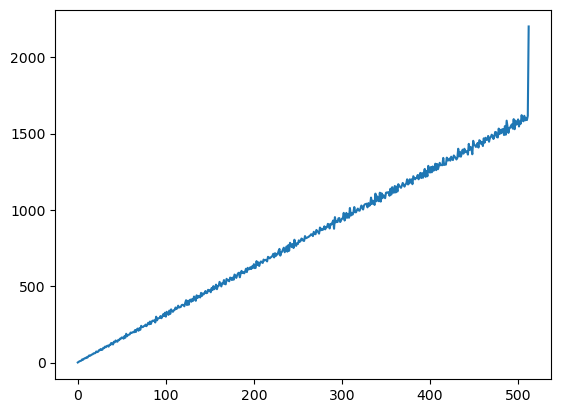

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x14c85011b610>

In [12]:
plt.plot(iso_norm)

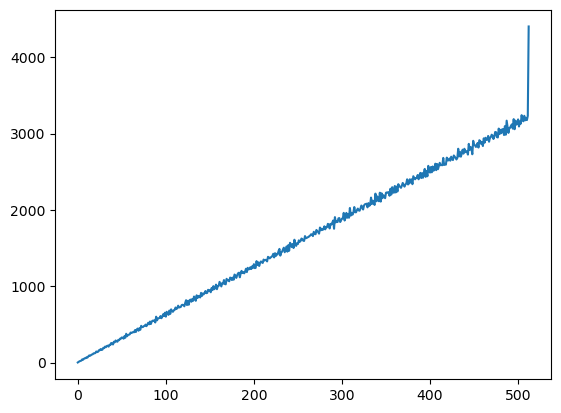

(513, 1024)

In [139]:
plt.plot(iso_norm)

size(a["jld_data"]["CBC"])

# Checking which files we have

# Fig. 1: f-plane budgets for different k*

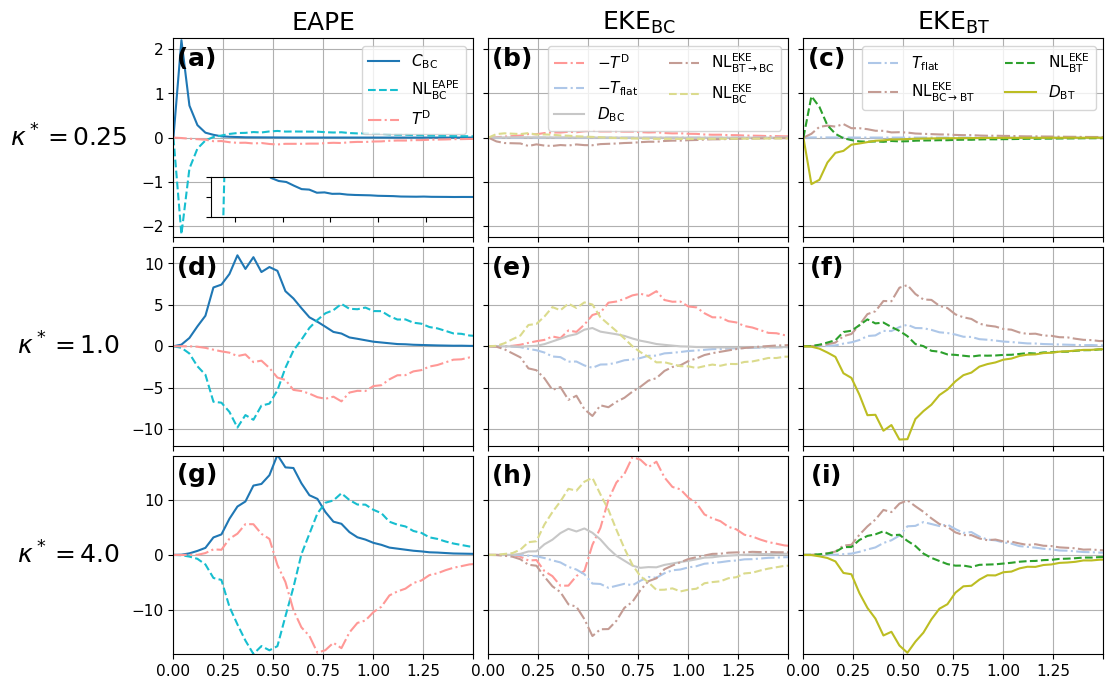

1-element Vector{Nothing}:
 nothing

In [28]:
function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool, ylims)

    h0 = (h0s[k], 0.0)
    kappa_loc = kappas[j]
    mu_loc = mus[i]
    
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

    beta = betas[7]

    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
    a = load(data_dir*jld_name_2L(model_params,71.95))
    

    norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1
    
    ##############################################################
    # EAPE budget
    ##############################################################
    # trans_resid = -(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .+ 2 .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] )    
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm .* iso_norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm .* iso_norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
    # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
    ax1.plot(grid.kr*Ld,a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm .* iso_norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

    if i==2
        # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
        axins = ax1.inset_axes([0.125, 0.1, 1-0.125, 0.2])

        axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm .* iso_norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
        axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm .* iso_norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
        # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
        axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm .* iso_norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

        axins.set_xlim(0.125, 1.5)
        axins.set_ylim(-0.005, 0.005)

        axins.set_yticklabels([])
        axins.set_xticklabels([])
        
    end
    
    
    ##############################################################
    # BC EKE budget
    ##############################################################
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm .* iso_norm, label=L"-T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm .* iso_norm, label=L"-T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
    # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm  .* iso_norm, label=L"D_\mathrm{BC}", color=tab20_color(16), linestyle="solid")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm  .* iso_norm, label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm  .* iso_norm, label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BC}", color=tab20_color(18), linestyle="dashed")    
    
    
    
    
    ##############################################################
    # BT EKE budget
    ##############################################################
    
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm .* iso_norm, label=L"T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm .* iso_norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot")
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm .* iso_norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed")
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm  .* iso_norm, label=L"D_\mathrm{BT}", color=tab20_color(17), linestyle="solid")
    
    
    
    ax1.set_xlim(0., 1.5)
    ax2.set_xlim(0., 1.5)
    ax3.set_xlim(0., 1.5)

    # ax1.set_ylim(-0.25, 0.25)
    # ax2.set_ylim(-0.25, 0.25)
    # ax3.set_ylim(-0.25, 0.25)

    ax1.set_ylim(ylims[1], ylims[2])
    ax2.set_ylim(ylims[1], ylims[2])
    ax3.set_ylim(ylims[1], ylims[2])

    if legend_bool==true
        ax1.legend(fontsize = lsize, loc="upper right")
        ax2.legend(fontsize = lsize, loc="upper right", ncols=2)
        ax3.legend(fontsize = lsize, loc="upper right", ncols=2)
    end

    ax1.grid()
    ax2.grid()
    ax3.grid()

    

end

###################################################################################
###################################################################################

fig,ax = plt.subplots(3,3, figsize=(12,8))

fsize = 18
lsize = 11

###################################################################################
###################################################################################

plot_budget(ax[1], ax[4], ax[7], 2, 1, 7, true, [-2.25, 2.25])

plot_budget(ax[2], ax[5], ax[8], 4, 1, 7, false, [-12, 12])

plot_budget(ax[3], ax[6], ax[9], 6, 1, 7, false, [-18, 18])


###################################################################################
###################################################################################


for axn in ax[4:end]
    axn.set_yticklabels([])
end
for axn in [ax[1:2]; ax[4:5]; ax[7:8]]
    axn.set_xticklabels([])
end

for i in range(1,length(ax))
    axn = ax[i]
    axn.tick_params(labelsize=lsize)
end

ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
ax[3].text(0.075, 0.9, L"\mathbf{(g)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
ax[4].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
ax[5].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
ax[6].text(0.075, 0.9, L"\mathbf{(h)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);
ax[7].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[7].transAxes);
ax[8].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[8].transAxes);
ax[9].text(0.075, 0.9, L"\mathbf{(i)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[9].transAxes);

ax[1].set_title(L"\mathrm{EAPE}", fontsize = fsize)
ax[4].set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
ax[7].set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

ax[1].text(-0.35, 0.5, L"\kappa^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
ax[2].text(-0.35, 0.5, L"\kappa^* = 1.0", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
ax[3].text(-0.35, 0.5, L"\kappa^* = 4.0", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);

###################################################################################
###################################################################################

plt.subplots_adjust(wspace=0.05, hspace=0.05)

plt.setp(ax[3].get_xticklabels()[end], visible=false)
plt.setp(ax[6].get_xticklabels()[end], visible=false)
plt.setp(ax[9].get_xticklabels()[end], visible=false)


###################################################################################
###################################################################################

# savefig("./JFM_BC_nrg_figs/kappas_beta0_1Dspectra.pdf",bbox_inches="tight")


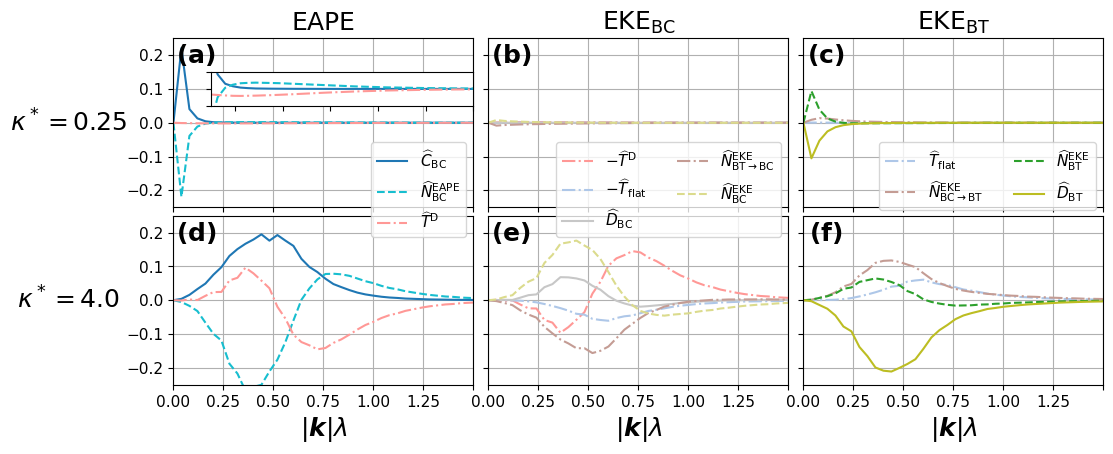

In [38]:
function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool)

    h0 = (h0s[k], 0.0)
    kappa_loc = kappas[j]
    mu_loc = mus[i]
    
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

    beta = betas[7]

    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
    a = load(data_dir*jld_name_2L(model_params,71.95))
    

    norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1
    
    ##############################################################
    # EAPE budget
    ##############################################################
    # trans_resid = -(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .+ 2 .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] )    
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"\widehat{C}_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\widehat{N}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
    # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
    ax1.plot(grid.kr*Ld,a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

    if i==2
        # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
        axins = ax1.inset_axes([0.125, 0.6, 1-0.125, 0.2])

        axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"\widehat{C}_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
        axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\widehat{N}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
        # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
        axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

        axins.set_xlim(0.125, 1.5)
        axins.set_ylim(-0.005, 0.005)

        axins.set_yticklabels([])
        axins.set_xticklabels([])
        
    end
    
    
    ##############################################################
    # BC EKE budget
    ##############################################################
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"-\widehat{T}_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
    # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"\widehat{D}_\mathrm{BC}", color=tab20_color(16), linestyle="solid")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\widehat{N}^\mathrm{EKE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\widehat{N}^\mathrm{EKE}_\mathrm{BC}", color=tab20_color(18), linestyle="dashed")    
    
    
    
    
    ##############################################################
    # BT EKE budget
    ##############################################################
    
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"\widehat{T}_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot")
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\widehat{N}^\mathrm{EKE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed")
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"\widehat{D}_\mathrm{BT}", color=tab20_color(17), linestyle="solid")
    
    
    
    ax1.set_xlim(0., 1.5)
    ax2.set_xlim(0., 1.5)
    ax3.set_xlim(0., 1.5)

    ax1.set_ylim(-0.25, 0.25)
    ax2.set_ylim(-0.25, 0.25)
    ax3.set_ylim(-0.25, 0.25)

    if legend_bool==true
        ax1.legend(fontsize = lsize, loc="upper right", bbox_to_anchor=(1.0, 0.43))
        ax2.legend(fontsize = lsize, loc="upper right", ncols=2, bbox_to_anchor=(1.0, 0.43))
        ax3.legend(fontsize = lsize, loc="upper right", ncols=2, bbox_to_anchor=(1.0, 0.43))
    end

    ax1.grid()
    ax2.grid()
    ax3.grid()

    

end

###################################################################################
###################################################################################

fig,ax = plt.subplots(2,3, figsize=(12,4.5))

fsize = 18
lsize = 11

###################################################################################
###################################################################################

plot_budget(ax[1], ax[3], ax[5], 2, 1, 7, true)

plot_budget(ax[2], ax[4], ax[6], 6, 1, 7, false)


###################################################################################
###################################################################################


for axn in ax[3:end]
    axn.set_yticklabels([])
end
for axn in [ax[1]; ax[3]; ax[5]]
    axn.set_xticklabels([])
end

for i in range(1,length(ax))
    axn = ax[i]
    axn.tick_params(labelsize=lsize)
end

ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
ax[3].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
ax[4].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
ax[5].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
ax[6].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);

ax[1].set_title(L"\mathrm{EAPE}", fontsize = fsize)
ax[3].set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
ax[5].set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

ax[2].set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
ax[4].set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
ax[6].set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)

ax[1].text(-0.35, 0.5, L"\kappa^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
ax[2].text(-0.35, 0.5, L"\kappa^* = 4.0", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);

###################################################################################
###################################################################################

plt.subplots_adjust(wspace=0.05, hspace=0.05)

plt.setp(ax[2].get_xticklabels()[end], visible=false)
plt.setp(ax[4].get_xticklabels()[end], visible=false)
plt.setp(ax[6].get_xticklabels()[end], visible=false)

ax[2].set_zorder(-1)
ax[4].set_zorder(-1)
ax[6].set_zorder(-1)

###################################################################################
###################################################################################

# savefig("./JFM_BC_nrg_figs/kappas_beta0_1Dspectra.pdf",bbox_inches="tight")


In [ ]:

# function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool, ylims)

#     h0 = (h0s[k], 0.0)
#     kappa_loc = kappas[j]
#     mu_loc = mus[i]
    
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
#     global topo_PV, eta = define_topo(model_params)
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

#     beta = betas[7]

#     global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
#     a = load(data_dir*jld_name_2L(model_params,71.95))
    

#     norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1 .* iso_norm
    
#     ##############################################################
#     # EAPE budget
#     ##############################################################
#     # trans_resid = -(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .+ 2 .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] )    
#     ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"\widehat{C}_\mathrm{BC}", color=tab20_color(1), linestyle="solid", linewidth=lwax)
#     ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\widehat{N}^\mathrm{PE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed", linewidth=lwax)
#     # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     ax1.plot(grid.kr*Ld,a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)

#     resid_EAPE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4]

#     ax1.plot(grid.kr*Ld,resid_EAPE .* norm, color="black", alpha=1.0, linewidth=0.5)
    
#     # if i==2
#     #     # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#     #     # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
#     #     axins = ax1.inset_axes([0.125, 0.6, 1-0.125, 0.2])

#     #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"\widehat{C}_\mathrm{BC}", color=tab20_color(1), linestyle="solid", linewidth=lwax)
#     #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\widehat{N}^\mathrm{PE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed", linewidth=lwax)
#     #     # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)

#     #     axins.plot(grid.kr*Ld,resid_EAPE .* norm, color="black", alpha=1.0, linewidth=0.5)
        
#     #     axins.set_xlim(0.125, 1.5)
#     #     axins.set_ylim(-0.005, 0.005)

#     #     axins.set_yticklabels([])
#     #     axins.set_xticklabels([])
        
#     # end
    
    
#     ##############################################################
#     # BC EKE budget
#     ##############################################################
#     ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)
#     ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"-\widehat{T}_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot", linewidth=lwax)
#     # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
#     ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"\widehat{D}_\mathrm{BC}", color=tab20_color(16), linestyle="solid", linewidth=lwax)
#     ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\widehat{N}^\mathrm{KE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot", linewidth=lwax)
#     ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\widehat{N}^\mathrm{KE}_\mathrm{BC}", color=tab20_color(18), linestyle="dashed", linewidth=lwax)    

#     resid_BC_EKE = -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .- a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13]
    
#     ax2.plot(grid.kr*Ld,resid_BC_EKE .* norm, color="black", alpha=1.0, linewidth=0.5)

#     ##############################################################
#     # BT EKE budget
#     ##############################################################
    
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"\widehat{T}_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot", linewidth=lwax)
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\widehat{N}^\mathrm{KE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot", linewidth=lwax)
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\widehat{N}^\mathrm{KE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed", linewidth=lwax)
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"\widehat{D}_\mathrm{BT}", color=tab20_color(17), linestyle="solid", linewidth=lwax)
    
#     resid_BT_EKE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8]

#     ax3.plot(grid.kr*Ld,resid_BT_EKE .* norm, color="black", alpha=1.0, linewidth=0.5)
    
#     ##############################################################
#     # extras
#     ##############################################################
    
    
#     ax1.set_xlim(0., 1.5)
#     ax2.set_xlim(0., 1.5)
#     ax3.set_xlim(0., 1.5)

#     # ax1.set_ylim(-0.25, 0.25)
#     # ax2.set_ylim(-0.25, 0.25)
#     # ax3.set_ylim(-0.25, 0.25)

#     ax1.set_ylim(ylims[1], ylims[2])
#     ax2.set_ylim(ylims[1], ylims[2])
#     ax3.set_ylim(ylims[1], ylims[2])

#     if legend_bool==true
#         ax1.legend(loc="upper right", fontsize=lsize, bbox_to_anchor=(0.925, -1.35), ncols=2)
#         ax2.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.1, -1.35))
#         ax3.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.2, -1.35))
#     end

#     ax1.grid(alpha=0.3)
#     ax2.grid(alpha=0.3)
#     ax3.grid(alpha=0.3)

    

# end

# ###################################################################################
# ###################################################################################

# # fig = PyPlot.figure(figsize=(12,4.5))

# # gs = fig.add_gridspec(2,4)
# # ax1 = fig.add_subplot(gs[1,1])
# # ax2 = fig.add_subplot(gs[2,1])
# # ax3 = fig.add_subplot(gs[1,2])
# # ax4 = fig.add_subplot(gs[2,2])
# # ax5 = fig.add_subplot(gs[1,3])
# # ax6 = fig.add_subplot(gs[2,3])

# # ax7 = fig.add_subplot(gs[1:2, 4])

# fig, axd = plt.subplot_mosaic([["ax1", "ax3", "ax5", "axnull", "ax7"],["ax2", "ax4", "ax6", "axnull", "ax7"]],
#     figsize=(14,5), gridspec_kw=Dict("wspace"=>0.05, "hspace"=>0.05), width_ratios=[1,1,1,0.25,1])

# axd["axnull"].axis("off")

# ax1 = axd["ax1"]
# ax2 = axd["ax2"]
# ax3 = axd["ax3"]
# ax4 = axd["ax4"]
# ax5 = axd["ax5"]
# ax6 = axd["ax6"]

# ax7 = axd["ax7"]


# # fig,ax = plt.subplots(2,3, figsize=(12,4.5))

# fsize = 18
# lsize = 14

# lwax=2.0

# ###################################################################################
# ###################################################################################

# plot_budget(ax1, ax3, ax5, 2, 1, 7, true, [-1.25, 1.25])

# plot_budget(ax2, ax4, ax6, 6, 1, 7, false, [-10, 10])


# ###################################################################################
# ###################################################################################


# for axn in [ax3;ax4;ax5;ax6]
#     axn.set_yticklabels([])
# end
# for axn in [ax1; ax3; ax5]
#     axn.set_xticklabels([])
# end

# for axn in [ax1;ax2;ax3;ax4;ax5;ax6]
#     axn.tick_params(labelsize=lsize)
# end

# ax1.text(0.1, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
# ax2.text(0.1, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);
# ax3.text(0.1, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax3.transAxes);
# ax4.text(0.1, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax4.transAxes);
# ax5.text(0.1, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes);
# ax6.text(0.1, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax6.transAxes);

# ax1.set_title(L"\mathrm{EAPE}", fontsize = fsize)
# ax3.set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
# ax5.set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

# ax2.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
# ax4.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
# ax6.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)

# ax5.text(0.75, 0.8, L"\kappa^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes, color="red");
# ax6.text(0.75, 0.8, L"\kappa^* = 4.0", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax6.transAxes, color="red");

# ###################################################################################
# ###################################################################################

# # plt.subplots_adjust(wspace=0.05, hspace=0.05)

# plt.setp(ax2.get_xticklabels()[end], visible=false)
# plt.setp(ax4.get_xticklabels()[end], visible=false)
# # plt.setp(ax6.get_xticklabels()[end], visible=false)

# ax2.set_zorder(-1)
# ax4.set_zorder(-1)
# ax6.set_zorder(-1)

# ###################################################################################
# ###################################################################################
# # coherence plot for kappa*=4.0, beta* = 0.

# tsize = 16

# x = prob.grid.kr .* Ld

# ############################################################################################
# # strong-drag f-plane
# ############################################################################################

# mu_loc = mus[6]
# beta = betas[7]

# global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, 0., (0., 0.), (0., 0.))
# global model_params = redef_mu_kappa_beta(model_params, mu_loc, 0., beta)

# a = load(data_dir*jld_name_2L(model_params,71.95))

# #####################

# ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{D})", linewidth=2.0)
# ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{N}^\mathrm{KE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
# ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{KE}, \, \widehat{N}^\mathrm{KE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
# ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{KE}, \,  \widehat{T}^\mathrm{D})", linewidth=2.0)

# ############################################################################################

# ax7.set_xlim(x[2], 1.5)

# ax7.set_ylim(0., 1.)

# ax7.legend(loc="upper right", fontsize = lsize, ncols=1, bbox_to_anchor=(0.9, -0.15))

# ax7.grid()

# ax7.set_xlabel(L"|\boldsymbol{k}| \, \lambda", fontsize = fsize)


# ax7.set_ylabel(L"\mathrm{Coherence}", fontsize = fsize)

# ax7.tick_params(axis="both", labelsize=lsize)

# ############################################################################################

# ax7.set_title(L"\mathbf{(g)} \ \kappa^* = 4.0, \, \beta^* = 0.0", fontsize=tsize)

# ############################################################################################


# ###################################################################################
# ###################################################################################


# # savefig("./JFM_BC_nrg_figs/kappas_beta0_1Dspectra.pdf",bbox_inches="tight")



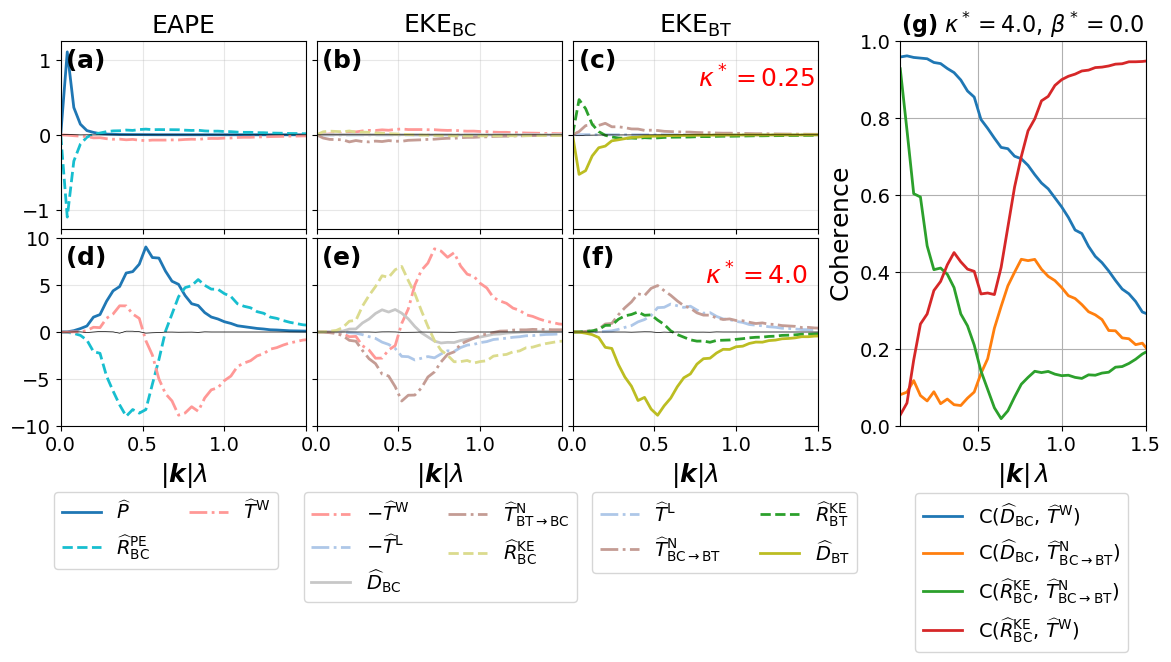

In [31]:

function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool, ylims)

    h0 = (h0s[k], 0.0)
    kappa_loc = kappas[j]
    mu_loc = mus[i]
    
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

    beta = betas[7]

    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
    a = load(data_dir*jld_name_2L(model_params,71.95))
    

    norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1 .* iso_norm
    
    ##############################################################
    # EAPE budget
    ##############################################################
    # trans_resid = -(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .+ 2 .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] )    
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"\widehat{P}", color=tab20_color(1), linestyle="solid", linewidth=lwax)
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\widehat{R}^\mathrm{PE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed", linewidth=lwax)
    # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
    ax1.plot(grid.kr*Ld,a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"\widehat{T}^\mathrm{W}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)

    resid_EAPE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4]

    ax1.plot(grid.kr*Ld,resid_EAPE .* norm, color="black", alpha=1.0, linewidth=0.5)
    
    # if i==2
    #     # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    #     # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
    #     axins = ax1.inset_axes([0.125, 0.6, 1-0.125, 0.2])

    #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"\widehat{C}_\mathrm{BC}", color=tab20_color(1), linestyle="solid", linewidth=lwax)
    #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\widehat{N}^\mathrm{PE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed", linewidth=lwax)
    #     # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
    #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)

    #     axins.plot(grid.kr*Ld,resid_EAPE .* norm, color="black", alpha=1.0, linewidth=0.5)
        
    #     axins.set_xlim(0.125, 1.5)
    #     axins.set_ylim(-0.005, 0.005)

    #     axins.set_yticklabels([])
    #     axins.set_xticklabels([])
        
    # end
    
    
    ##############################################################
    # BC EKE budget
    ##############################################################
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-\widehat{T}^\mathrm{W}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"\widehat{T}^\mathrm{L}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(2), linestyle="dashdot", linewidth=lwax)
    # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"\widehat{D}_\mathrm{BC}", color=tab20_color(16), linestyle="solid", linewidth=lwax)
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\widehat{T}^\mathrm{N}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot", linewidth=lwax)
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\widehat{R}^\mathrm{KE}_\mathrm{BC}", color=tab20_color(18), linestyle="dashed", linewidth=lwax)    

    resid_BC_EKE = -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .- a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13]
    
    ax2.plot(grid.kr*Ld,resid_BC_EKE .* norm, color="black", alpha=1.0, linewidth=0.5)

    ##############################################################
    # BT EKE budget
    ##############################################################
    
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"\widehat{T}^\mathrm{L}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(2), linestyle="dashdot", linewidth=lwax)
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\widehat{T}^\mathrm{N}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot", linewidth=lwax)
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\widehat{R}^\mathrm{KE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed", linewidth=lwax)
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"\widehat{D}_\mathrm{BT}", color=tab20_color(17), linestyle="solid", linewidth=lwax)
    
    resid_BT_EKE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8]

    ax3.plot(grid.kr*Ld,resid_BT_EKE .* norm, color="black", alpha=1.0, linewidth=0.5)
    
    ##############################################################
    # extras
    ##############################################################
    
    
    ax1.set_xlim(0., 1.5)
    ax2.set_xlim(0., 1.5)
    ax3.set_xlim(0., 1.5)

    # ax1.set_ylim(-0.25, 0.25)
    # ax2.set_ylim(-0.25, 0.25)
    # ax3.set_ylim(-0.25, 0.25)

    ax1.set_ylim(ylims[1], ylims[2])
    ax2.set_ylim(ylims[1], ylims[2])
    ax3.set_ylim(ylims[1], ylims[2])

    if legend_bool==true
        ax1.legend(loc="upper right", fontsize=lsize, bbox_to_anchor=(0.925, -1.35), ncols=2)
        ax2.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.1, -1.35))
        ax3.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.2, -1.35))
    end

    ax1.grid(alpha=0.3)
    ax2.grid(alpha=0.3)
    ax3.grid(alpha=0.3)

    

end

###################################################################################
###################################################################################

# fig = PyPlot.figure(figsize=(12,4.5))

# gs = fig.add_gridspec(2,4)
# ax1 = fig.add_subplot(gs[1,1])
# ax2 = fig.add_subplot(gs[2,1])
# ax3 = fig.add_subplot(gs[1,2])
# ax4 = fig.add_subplot(gs[2,2])
# ax5 = fig.add_subplot(gs[1,3])
# ax6 = fig.add_subplot(gs[2,3])

# ax7 = fig.add_subplot(gs[1:2, 4])

fig, axd = plt.subplot_mosaic([["ax1", "ax3", "ax5", "axnull", "ax7"],["ax2", "ax4", "ax6", "axnull", "ax7"]],
    figsize=(14,5), gridspec_kw=Dict("wspace"=>0.05, "hspace"=>0.05), width_ratios=[1,1,1,0.25,1])

axd["axnull"].axis("off")

ax1 = axd["ax1"]
ax2 = axd["ax2"]
ax3 = axd["ax3"]
ax4 = axd["ax4"]
ax5 = axd["ax5"]
ax6 = axd["ax6"]

ax7 = axd["ax7"]


# fig,ax = plt.subplots(2,3, figsize=(12,4.5))

fsize = 18
lsize = 14

lwax=2.0

###################################################################################
###################################################################################

plot_budget(ax1, ax3, ax5, 2, 1, 7, true, [-1.25, 1.25])

plot_budget(ax2, ax4, ax6, 6, 1, 7, false, [-10, 10])


###################################################################################
###################################################################################


for axn in [ax3;ax4;ax5;ax6]
    axn.set_yticklabels([])
end
for axn in [ax1; ax3; ax5]
    axn.set_xticklabels([])
end

for axn in [ax1;ax2;ax3;ax4;ax5;ax6]
    axn.tick_params(labelsize=lsize)
end

ax1.text(0.1, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
ax2.text(0.1, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);
ax3.text(0.1, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax3.transAxes);
ax4.text(0.1, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax4.transAxes);
ax5.text(0.1, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes);
ax6.text(0.1, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax6.transAxes);

ax1.set_title(L"\mathrm{EAPE}", fontsize = fsize)
ax3.set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
ax5.set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

ax2.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
ax4.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
ax6.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)

ax5.text(0.75, 0.8, L"\kappa^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes, color="red");
ax6.text(0.75, 0.8, L"\kappa^* = 4.0", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax6.transAxes, color="red");

###################################################################################
###################################################################################

# plt.subplots_adjust(wspace=0.05, hspace=0.05)

plt.setp(ax2.get_xticklabels()[end], visible=false)
plt.setp(ax4.get_xticklabels()[end], visible=false)
# plt.setp(ax6.get_xticklabels()[end], visible=false)

ax2.set_zorder(-1)
ax4.set_zorder(-1)
ax6.set_zorder(-1)

###################################################################################
###################################################################################
# coherence plot for kappa*=4.0, beta* = 0.

tsize = 16

x = prob.grid.kr .* Ld

############################################################################################
# strong-drag f-plane
############################################################################################

mu_loc = mus[6]
beta = betas[7]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, 0., (0., 0.), (0., 0.))
global model_params = redef_mu_kappa_beta(model_params, mu_loc, 0., beta)

a = load(data_dir*jld_name_2L(model_params,71.95))

#####################

ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{W})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{N}_{\mathrm{BT} \rightarrow \mathrm{BC}})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{R}_\mathrm{BC}^\mathrm{KE}, \, \widehat{T}^\mathrm{N}_{\mathrm{BT} \rightarrow \mathrm{BC}})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{R}_\mathrm{BC}^\mathrm{KE}, \,  \widehat{T}^\mathrm{W})", linewidth=2.0)

############################################################################################

ax7.set_xlim(x[2], 1.5)

ax7.set_ylim(0., 1.)

ax7.legend(loc="upper right", fontsize = lsize, ncols=1, bbox_to_anchor=(0.9675, -0.15))

ax7.grid()

ax7.set_xlabel(L"|\boldsymbol{k}| \, \lambda", fontsize = fsize)


ax7.set_ylabel(L"\mathrm{Coherence}", fontsize = fsize)

ax7.tick_params(axis="both", labelsize=lsize)

############################################################################################

ax7.set_title(L"\mathbf{(g)} \ \kappa^* = 4.0, \, \beta^* = 0.0", fontsize=tsize)

############################################################################################


###################################################################################
###################################################################################


savefig("./JFM_BC_nrg_figs/kappas_beta0_1Dspectra.pdf",bbox_inches="tight")



In [14]:
# function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool)

#     h0 = (h0s[k], 0.0)
#     kappa_loc = kappas[j]
#     mu_loc = mus[i]
    
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
#     global topo_PV, eta = define_topo(model_params)
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

#     beta = betas[7]

#     global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
#     a = load(data_dir*jld_name_2L(model_params,71.95))
    

#     norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld
#     println(a["jld_data"]["two_layer_vBT_scale"])
    
#     ##############################################################
#     # EAPE budget
#     ##############################################################
#     # trans_resid = -(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .+ 2 .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] )    
#     ax1.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#     ax1.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#     # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     ax1.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#     if i==2
#         # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#         # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
#         axins = ax1.inset_axes([0.125, 0.1, 1-0.125, 0.2])

#         axins.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#         axins.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#         # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#         axins.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#         axins.set_xlim(0.125, 1.5)
#         axins.set_ylim(-0.005, 0.005)

#         axins.set_yticklabels([])
#         axins.set_xticklabels([])
        
#     end
    
    
#     ##############################################################
#     # BC EKE budget
#     ##############################################################
#     ax2.plot(grid.kr*Ld, -grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, -grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"-T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
#     ax2.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"D_\mathrm{BC}", color=tab20_color(16), linestyle="solid")
#     ax2.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BC}", color=tab20_color(14), linestyle="dashed")    
    
    
    
    
#     ##############################################################
#     # BT EKE budget
#     ##############################################################
    
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed")
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BT}", color=tab20_color(17), linestyle="solid")
    
    
    
#     ax1.set_xlim(grid.kr[2]*Ld, 1.5)
#     ax2.set_xlim(grid.kr[2]*Ld, 1.5)
#     ax3.set_xlim(grid.kr[2]*Ld, 1.5)

#     ax1.set_xscale("log")
#     ax2.set_xscale("log")
#     ax3.set_xscale("log")
    
#     # ax1.set_ylim(-0.25, 0.25)
#     # ax2.set_ylim(-0.25, 0.25)
#     # ax3.set_ylim(-0.25, 0.25)

#     if legend_bool==true
#         ax1.legend(fontsize = lsize, loc="upper right")
#         ax2.legend(fontsize = lsize, loc="upper right", ncols=2)
#         ax3.legend(fontsize = lsize, loc="upper right", ncols=2)
#     end

#     ax1.grid()
#     ax2.grid()
#     ax3.grid()

    

# end

# ###################################################################################
# ###################################################################################

# fig,ax = plt.subplots(3,3, figsize=(12,8))
# fig.tight_layout(pad=0.)

# fsize = 20
# lsize = 14

# ###################################################################################
# ###################################################################################

# plot_budget(ax[1], ax[4], ax[7], 2, 1, 7, true)

# plot_budget(ax[2], ax[5], ax[8], 4, 1, 7, false)

# plot_budget(ax[3], ax[6], ax[9], 6, 1, 7, false)


# ###################################################################################
# ###################################################################################


# for axn in ax[4:end]
#     axn.set_yticklabels([])
# end
# for axn in [ax[1:2]; ax[4:5]; ax[7:8]]
#     axn.set_xticklabels([])
# end

# for i in range(1,length(ax))
#     axn = ax[i]
#     axn.tick_params(labelsize=lsize)
# end

# ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
# ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
# ax[3].text(0.075, 0.9, L"\mathbf{(g)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
# ax[4].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
# ax[5].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
# ax[6].text(0.075, 0.9, L"\mathbf{(h)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);
# ax[7].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[7].transAxes);
# ax[8].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[8].transAxes);
# ax[9].text(0.075, 0.9, L"\mathbf{(i)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[9].transAxes);


# ax[1].set_title(L"\mathrm{EAPE}", fontsize = fsize)
# ax[4].set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
# ax[7].set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

# ax[1].text(-0.4, 0.5, L"\kappa^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
# ax[2].text(-0.4, 0.5, L"\kappa^* = 1.0", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
# ax[3].text(-0.4, 0.5, L"\kappa^* = 4.0", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);

# ###################################################################################
# ###################################################################################





In [15]:
# function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool)

#     h0 = (h0s[k], 0.0)
#     kappa_loc = kappas[j]
#     mu_loc = mus[i]
    
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
#     global topo_PV, eta = define_topo(model_params)
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

#     beta = betas[10]

#     global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
#     a = load(data_dir*jld_name(model_params,71.95))
    

#     norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld
#     println(a["jld_data"]["two_layer_vBT_scale"])
    
#     ##############################################################
#     # EAPE budget
#     ##############################################################
#     # trans_resid = -(a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .+ 2 .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] )    
#     ax1.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#     ax1.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#     # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     ax1.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#     if i==2
#         # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#         # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
#         axins = ax1.inset_axes([0.125, 0.1, 1-0.125, 0.2])

#         axins.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#         axins.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#         # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#         axins.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#         axins.set_xlim(0.125, 1.5)
#         axins.set_ylim(-0.005, 0.005)

#         axins.set_yticklabels([])
#         axins.set_xticklabels([])
        
#     end
    
    
#     ##############################################################
#     # BC EKE budget
#     ##############################################################
#     ax2.plot(grid.kr*Ld, -grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, -grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"-T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
#     ax2.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"D_\mathrm{BC}", color=tab20_color(16), linestyle="solid")
#     ax2.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BC}", color=tab20_color(14), linestyle="dashed")    
    
    
    
    
#     ##############################################################
#     # BT EKE budget
#     ##############################################################
    
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed")
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BT}", color=tab20_color(17), linestyle="solid")
    
    
    
#     ax1.set_xlim(0., 1.5)
#     ax2.set_xlim(0., 1.5)
#     ax3.set_xlim(0., 1.5)

#     # ax1.set_ylim(-0.25, 0.25)
#     # ax2.set_ylim(-0.25, 0.25)
#     # ax3.set_ylim(-0.25, 0.25)

#     if legend_bool==true
#         ax1.legend(fontsize = lsize, loc="upper right")
#         ax2.legend(fontsize = lsize, loc="upper right", ncols=2)
#         ax3.legend(fontsize = lsize, loc="upper right", ncols=2)
#     end

#     ax1.grid()
#     ax2.grid()
#     ax3.grid()

    

# end

# ###################################################################################
# ###################################################################################

# fig,ax = plt.subplots(3,3, figsize=(12,8))
# fig.tight_layout(pad=0.)

# fsize = 20
# lsize = 14

# ###################################################################################
# ###################################################################################

# plot_budget(ax[1], ax[4], ax[7], 2, 1, 7, true)

# plot_budget(ax[2], ax[5], ax[8], 4, 1, 7, false)

# plot_budget(ax[3], ax[6], ax[9], 6, 1, 7, false)


# ###################################################################################
# ###################################################################################


# for axn in ax[4:end]
#     axn.set_yticklabels([])
# end
# for axn in [ax[1:2]; ax[4:5]; ax[7:8]]
#     axn.set_xticklabels([])
# end

# for i in range(1,length(ax))
#     axn = ax[i]
#     axn.tick_params(labelsize=lsize)
# end

# ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
# ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
# ax[3].text(0.075, 0.9, L"\mathbf{(g)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
# ax[4].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
# ax[5].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
# ax[6].text(0.075, 0.9, L"\mathbf{(h)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);
# ax[7].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[7].transAxes);
# ax[8].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[8].transAxes);
# ax[9].text(0.075, 0.9, L"\mathbf{(i)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[9].transAxes);


# ax[1].set_title(L"\mathrm{EAPE}", fontsize = fsize)
# ax[4].set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
# ax[7].set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

# ax[1].text(-0.4, 0.5, L"\kappa^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
# ax[2].text(-0.4, 0.5, L"\kappa^* = 1.0", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
# ax[3].text(-0.4, 0.5, L"\kappa^* = 4.0", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);

# ###################################################################################
# ###################################################################################





In [35]:
# function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool)

#     h0 = (h0s[7], 0.0)
#     kappa_loc = kappas[j]
#     mu_loc = mus[i]
    
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
#     global topo_PV, eta = define_topo(model_params)
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

#     beta = betas[k]

#     global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
#     a = load(data_dir*jld_name(model_params,71.95))
    

#     # norm = a["jld_data"]["two_layer_vBT_scale"]^-3
#     norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^2
    
#     ##############################################################
#     # EAPE budget
#     ##############################################################    
#     ax1.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#     ax1.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#     # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     ax1.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#     # ax1.axvline((0.7 * a["jld_data"]["two_layer_vBT_scale"] / beta)^0.5 / (2 * pi * Ld))
#     # ax1.axvline((mu_loc / a["jld_data"]["two_layer_vBT_scale"])^-1 / (2 * pi * Ld))


#     # if i==2
#     #     # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#     #     # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
#     #     axins = ax1.inset_axes([0.125, 0.1, 1-0.125, 0.2])

#     #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#     #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#     #     # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     #     axins.plot(grid.kr*Ld, trans_resid .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#     #     axins.set_xlim(0.125, 1.5)
#     #     axins.set_ylim(-0.005, 0.005)

#     #     axins.set_yticklabels([])
#     #     axins.set_xticklabels([])
        
#     # end
    
    
#     ##############################################################
#     # BC EKE budget
#     ##############################################################
#     ax2.plot(grid.kr*Ld, -grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, -grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"-T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
#     ax2.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"D_\mathrm{BC}", color=tab20_color(16), linestyle="solid")
#     ax2.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BC}", color=tab20_color(20), linestyle="dashed")    
    
    
    
    
#     ##############################################################
#     # BT EKE budget
#     ##############################################################
    
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed")
#     ax3.plot(grid.kr*Ld, grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BT}", color=tab20_color(17), linestyle="solid")
    
    
    
#     ax1.set_xlim(0.05, 1.5)
#     ax2.set_xlim(0.05, 1.5)
#     ax3.set_xlim(0.05, 1.5)

#     # ax1.set_ylim(-0.25, 0.25)
#     # ax2.set_ylim(-0.25, 0.25)
#     # ax3.set_ylim(-0.25, 0.25)

#     if legend_bool==true
#         ax1.legend(loc="upper right")
#         ax2.legend(loc="upper right")
#         ax3.legend(loc="upper right")
#     end

#     ax1.grid()
#     ax2.grid()
#     ax3.grid()

#     ax1.set_xscale("log")
#     ax2.set_xscale("log")
#     ax3.set_xscale("log")

# end

# ###################################################################################
# ###################################################################################

# fig,ax = plt.subplots(3,3, figsize=(12,12))

# plot_budget(ax[1], ax[4], ax[7], 2, 1, 8, true)

# plot_budget(ax[2], ax[5], ax[8], 2, 1, 9, false)

# plot_budget(ax[3], ax[6], ax[9], 2, 1, 10, false)


# # plot_budget(ax[1], ax[4], ax[7], 2, 1, 7, true)

# # plot_budget(ax[2], ax[5], ax[8], 4, 1, 7, false)

# # plot_budget(ax[3], ax[6], ax[9], 6, 1, 7, false)



In [ ]:
# function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool)

#     h0 = (h0s[7], 0.0)
#     kappa_loc = kappas[j]
#     mu_loc = mus[i]
    
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
#     global topo_PV, eta = define_topo(model_params)
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

#     beta = betas[k]

#     global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
#     a = load(data_dir*jld_name(model_params,71.95))
    

#     norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1
    
#     ##############################################################
#     # EAPE budget
#     ##############################################################    
#     ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#     ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#     # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#     # ax1.axvline((0.7 * a["jld_data"]["two_layer_vBT_scale"] / beta)^0.5 / (2 * pi * Ld))
#     # ax1.axvline((mu_loc / a["jld_data"]["two_layer_vBT_scale"])^-1 / (2 * pi * Ld))


#     # if i==2
#     #     # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#     #     # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
#     #     axins = ax1.inset_axes([0.125, 0.1, 1-0.125, 0.2])

#     #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#     #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#     #     # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     #     axins.plot(grid.kr*Ld, trans_resid .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#     #     axins.set_xlim(0.125, 1.5)
#     #     axins.set_ylim(-0.005, 0.005)

#     #     axins.set_yticklabels([])
#     #     axins.set_xticklabels([])
        
#     # end
    
    
#     ##############################################################
#     # BC EKE budget
#     ##############################################################
#     ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"-T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
#     ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"D_\mathrm{BC}", color=tab20_color(16), linestyle="solid")
#     ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BC}", color=tab20_color(14), linestyle="dashed")    
    
    
    
    
#     ##############################################################
#     # BT EKE budget
#     ##############################################################
    
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"T_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\mathrm{NL}^\mathrm{EKE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed")
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BT}", color=tab20_color(17), linestyle="solid")
    
    
    
#     ax1.set_xlim(0., 1.5)
#     ax2.set_xlim(0., 1.5)
#     ax3.set_xlim(0., 1.5)

#     ax1.set_ylim(-0.25, 0.25)
#     ax2.set_ylim(-0.25, 0.25)
#     ax3.set_ylim(-0.25, 0.25)

#     if legend_bool==true
#         ax1.legend(loc="upper right", fontsize=lsize)
#         ax2.legend(loc="upper right", fontsize=lsize, ncols=2)
#         ax3.legend(loc="upper right", fontsize=lsize, ncols=2)
#     end

#     ax1.grid()
#     ax2.grid()
#     ax3.grid()

# end

# ###################################################################################
# ###################################################################################

# fig,ax = plt.subplots(3,3, figsize=(12,8))

# fsize = 18
# lsize = 11

# plot_budget(ax[1], ax[4], ax[7], 2, 1, 8, true)

# plot_budget(ax[2], ax[5], ax[8], 2, 1, 9, false)

# plot_budget(ax[3], ax[6], ax[9], 2, 1, 10, false)


# # plot_budget(ax[1], ax[4], ax[7], 2, 1, 7, true)

# # plot_budget(ax[2], ax[5], ax[8], 4, 1, 7, false)

# # plot_budget(ax[3], ax[6], ax[9], 6, 1, 7, false)

# ###################################################################################
# ###################################################################################

# for axn in ax[4:end]
#     axn.set_yticklabels([])
# end
# for axn in [ax[1:2]; ax[4:5]; ax[7:8]]
#     axn.set_xticklabels([])
# end

# for i in range(1,length(ax))
#     axn = ax[i]
#     axn.tick_params(labelsize=lsize)
# end

# ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
# ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
# ax[3].text(0.075, 0.9, L"\mathbf{(g)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
# ax[4].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
# ax[5].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
# ax[6].text(0.075, 0.9, L"\mathbf{(h)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);
# ax[7].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[7].transAxes);
# ax[8].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[8].transAxes);
# ax[9].text(0.075, 0.9, L"\mathbf{(i)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[9].transAxes);


# ###################################################################################
# ###################################################################################

# ax[1].set_title(L"\mathrm{EAPE}", fontsize = fsize)
# ax[4].set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
# ax[7].set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

# ax[1].text(-0.4, 0.5, L"\beta^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
# ax[2].text(-0.4, 0.5, L"\beta^* = 0.5", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
# ax[3].text(-0.4, 0.5, L"\beta^* = 0.75", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);

# plt.subplots_adjust(wspace=0.05, hspace=0.05)

# plt.setp(ax[3].get_xticklabels()[end], visible=false)
# plt.setp(ax[6].get_xticklabels()[end], visible=false)
# plt.setp(ax[9].get_xticklabels()[end], visible=false)

# ax[3].set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
# ax[6].set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
# ax[9].set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)


# ###################################################################################
# ###################################################################################


# # savefig("./JFM_BC_nrg_figs/kappa0p25_betas_1Dspectra.pdf",bbox_inches="tight")


In [27]:
# function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool)

#     h0 = (h0s[7], 0.0)
#     kappa_loc = kappas[j]
#     mu_loc = mus[i]
    
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
#     global topo_PV, eta = define_topo(model_params)
#     global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

#     beta = betas[k]

#     global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
#     a = load(data_dir*jld_name(model_params,71.95))
    

#     norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1
    
#     ##############################################################
#     # EAPE budget
#     ##############################################################    
#     ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"\widehat{C}_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#     ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\widehat{N}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#     # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#     # ax1.axvline((0.7 * a["jld_data"]["two_layer_vBT_scale"] / beta)^0.5 / (2 * pi * Ld))
#     # ax1.axvline((mu_loc / a["jld_data"]["two_layer_vBT_scale"])^-1 / (2 * pi * Ld))

#     resid_EAPE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4]

#     ax1.plot(grid.kr*Ld,resid_EAPE .* norm, color="gray", alpha=0.5, linewidth=0.5)
    
#     # if i==2
#     #     # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#     #     # axins = ax1.inset_axes(ax[1], width="30%", height="40%")
#     #     axins = ax1.inset_axes([0.125, 0.1, 1-0.125, 0.2])

#     #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"C_\mathrm{BC}", color=tab20_color(1), linestyle="solid")
#     #     axins.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\mathrm{NL}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed")
#     #     # axins.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
#     #     axins.plot(grid.kr*Ld, trans_resid .* norm, label=L"T^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")

#     #     axins.set_xlim(0.125, 1.5)
#     #     axins.set_ylim(-0.005, 0.005)

#     #     axins.set_yticklabels([])
#     #     axins.set_xticklabels([])
        
#     # end
    
    
#     ##############################################################
#     # BC EKE budget
#     ##############################################################
#     ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"-\widehat{T}_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
#     ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"\widehat{D}_\mathrm{BC}", color=tab20_color(16), linestyle="solid")
#     ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\widehat{N}^\mathrm{EKE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot")
#     ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\widehat{N}^\mathrm{EKE}_\mathrm{BC}", color=tab20_color(14), linestyle="dashed")    
    
#     resid_BC_EKE = -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .- a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13]
    
#     ax2.plot(grid.kr*Ld,resid_BC_EKE .* norm, color="gray", alpha=0.5, linewidth=0.5)

#     ##############################################################
#     # BT EKE budget
#     ##############################################################
    
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"\widehat{T}_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot")
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\widehat{N}^\mathrm{EKE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed")
#     ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"\widehat{D}_\mathrm{BT}", color=tab20_color(17), linestyle="solid")
    
    
#     resid_BT_EKE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8]

#     ax3.plot(grid.kr*Ld,resid_BT_EKE .* norm, color="gray", alpha=0.5, linewidth=0.5)

#     ##############################################################
#     # extras
#     ##############################################################
    
    
#     ax1.set_xlim(0., 1.5)
#     ax2.set_xlim(0., 1.5)
#     ax3.set_xlim(0., 1.5)

#     ax1.set_ylim(-0.25, 0.25)
#     ax2.set_ylim(-0.25, 0.25)
#     ax3.set_ylim(-0.25, 0.25)

#     if legend_bool==true
#         ax1.legend(loc="upper right", fontsize=lsize, bbox_to_anchor=(1.0, 0.43))
#         ax2.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.0, 0.43))
#         ax3.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.0, 0.43))
#     end

#     ax1.grid()
#     ax2.grid()
#     ax3.grid()

# end

# ###################################################################################
# ###################################################################################

# fig,ax = plt.subplots(2,3, figsize=(12,4.5))

# fsize = 18
# lsize = 11

# plot_budget(ax[1], ax[3], ax[5], 2, 1, 8, true)

# plot_budget(ax[2], ax[4], ax[6], 2, 1, 10, false)


# # plot_budget(ax[1], ax[4], ax[7], 2, 1, 7, true)

# # plot_budget(ax[2], ax[5], ax[8], 4, 1, 7, false)

# # plot_budget(ax[3], ax[6], ax[9], 6, 1, 7, false)

# ###################################################################################
# ###################################################################################

# for axn in ax[3:end]
#     axn.set_yticklabels([])
# end
# for axn in [ax[1]; ax[3]; ax[5]]
#     axn.set_xticklabels([])
# end

# for i in range(1,length(ax))
#     axn = ax[i]
#     axn.tick_params(labelsize=lsize)
# end

# ax[1].text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
# ax[2].text(0.075, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);
# ax[3].text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[3].transAxes);
# ax[4].text(0.075, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[4].transAxes);
# ax[5].text(0.075, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[5].transAxes);
# ax[6].text(0.075, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[6].transAxes);

# ###################################################################################
# ###################################################################################

# ax[1].set_title(L"\mathrm{EAPE}", fontsize = fsize)
# ax[3].set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
# ax[5].set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

# ax[1].text(-0.4, 0.5, L"\beta^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[1].transAxes);
# ax[2].text(-0.4, 0.5, L"\beta^* = 0.75", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax[2].transAxes);

# plt.subplots_adjust(wspace=0.05, hspace=0.05)

# plt.setp(ax[2].get_xticklabels()[end], visible=false)
# plt.setp(ax[4].get_xticklabels()[end], visible=false)
# plt.setp(ax[6].get_xticklabels()[end], visible=false)

# ax[2].set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
# ax[4].set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
# ax[6].set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)

# ax[2].set_zorder(-1)
# ax[4].set_zorder(-1)
# ax[6].set_zorder(-1)

# ###################################################################################
# ###################################################################################


# # savefig("./JFM_BC_nrg_figs/kappa0p25_betas_1Dspectra.pdf",bbox_inches="tight")


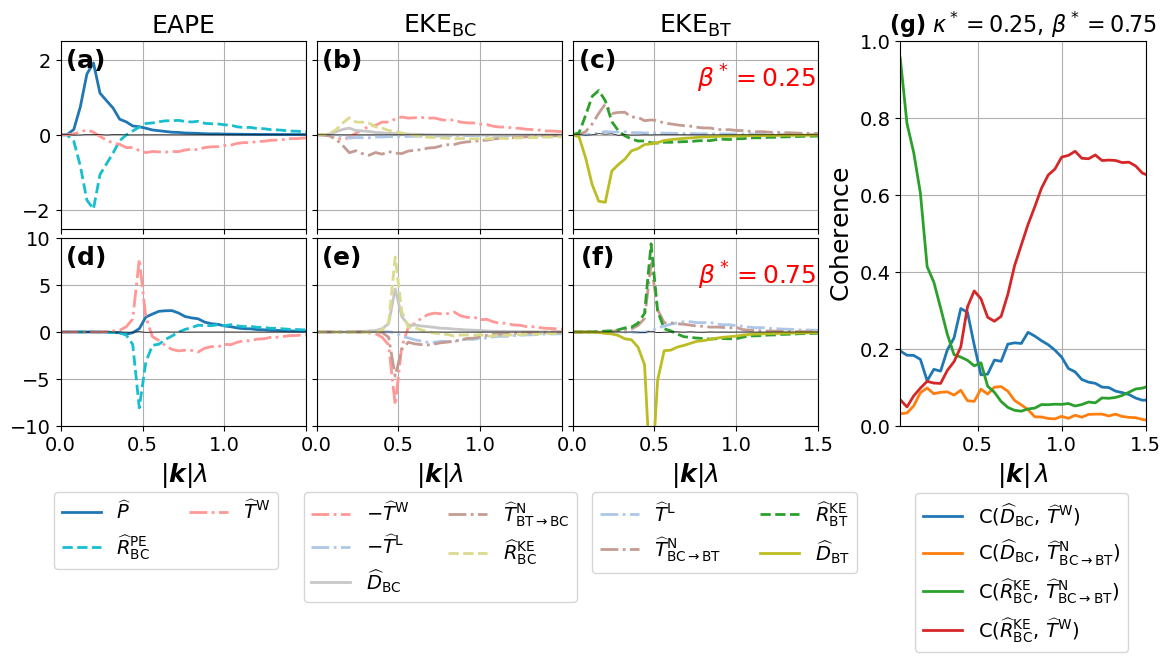

In [32]:
function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool, ylims)

    h0 = (h0s[7], 0.0)
    kappa_loc = kappas[j]
    mu_loc = mus[i]
    
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

    beta = betas[k]

    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
    a = load(data_dir*jld_name_2L(model_params,71.95))
    

    norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1 .* iso_norm
    
    ##############################################################
    # EAPE budget
    ##############################################################
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"\widehat{P}", color=tab20_color(1), linestyle="solid", linewidth=lwax)
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\widehat{R}^\mathrm{PE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed", linewidth=lwax)

    ax1.plot(grid.kr*Ld,a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"\widehat{T}^\mathrm{W}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)

    resid_EAPE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4]

    ax1.plot(grid.kr*Ld,resid_EAPE .* norm, color="black", alpha=1.0, linewidth=0.5)
    
    ##############################################################
    # BC EKE budget
    ##############################################################
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-\widehat{T}^\mathrm{W}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"\widehat{T}^\mathrm{L}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(2), linestyle="dashdot", linewidth=lwax)
    # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"\widehat{D}_\mathrm{BC}", color=tab20_color(16), linestyle="solid", linewidth=lwax)
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\widehat{T}^\mathrm{N}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot", linewidth=lwax)
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\widehat{R}^\mathrm{KE}_\mathrm{BC}", color=tab20_color(18), linestyle="dashed", linewidth=lwax)    

    resid_BC_EKE = -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .- a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13]
    
    ax2.plot(grid.kr*Ld,resid_BC_EKE .* norm, color="black", alpha=1.0, linewidth=0.5)

    ##############################################################
    # BT EKE budget
    ##############################################################
    
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"\widehat{T}^\mathrm{L}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(2), linestyle="dashdot", linewidth=lwax)
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\widehat{T}^\mathrm{N}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot", linewidth=lwax)
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\widehat{R}^\mathrm{KE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed", linewidth=lwax)
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"\widehat{D}_\mathrm{BT}", color=tab20_color(17), linestyle="solid", linewidth=lwax)
    
    resid_BT_EKE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8]

    ax3.plot(grid.kr*Ld,resid_BT_EKE .* norm, color="black", alpha=1.0, linewidth=0.5)
    
    ##############################################################
    # extras
    ##############################################################
    
    
    ax1.set_xlim(0., 1.5)
    ax2.set_xlim(0., 1.5)
    ax3.set_xlim(0., 1.5)

    ax1.set_ylim(ylims[1], ylims[2])
    ax2.set_ylim(ylims[1], ylims[2])
    ax3.set_ylim(ylims[1], ylims[2])

    if legend_bool==true
        ax1.legend(loc="upper right", fontsize=lsize, bbox_to_anchor=(0.925, -1.35), ncols=2)
        ax2.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.1, -1.35))
        ax3.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.2, -1.35))
    end

    ax1.grid()
    ax2.grid()
    ax3.grid()

end

###################################################################################
###################################################################################

# fig, axd = plt.subplot_mosaic([["ax1", "ax3", "ax5", "axnull", "ax7"],["ax2", "ax4", "ax6", "axnull", "ax7"]],
#     figsize=(14,5), gridspec_kw=Dict("wspace"=>0.05, "hspace"=>0.05), width_ratios=[1,1,1,0.25,1])

# axd["axnull"].axis("off")

# ax1 = axd["ax1"]
# ax2 = axd["ax2"]
# ax3 = axd["ax3"]
# ax4 = axd["ax4"]
# ax5 = axd["ax5"]
# ax6 = axd["ax6"]

# ax7 = axd["ax7"]


# # fig,ax = plt.subplots(2,3, figsize=(12,4.5))

# fsize = 18
# lsize = 12

# lwax=2.0

fig, axd = plt.subplot_mosaic([["ax1", "ax3", "ax5", "axnull", "ax7"],["ax2", "ax4", "ax6", "axnull", "ax7"]],
    figsize=(14,5), gridspec_kw=Dict("wspace"=>0.05, "hspace"=>0.05), width_ratios=[1,1,1,0.25,1])

axd["axnull"].axis("off")

ax1 = axd["ax1"]
ax2 = axd["ax2"]
ax3 = axd["ax3"]
ax4 = axd["ax4"]
ax5 = axd["ax5"]
ax6 = axd["ax6"]

ax7 = axd["ax7"]


# fig,ax = plt.subplots(2,3, figsize=(12,4.5))

fsize = 18
lsize = 14

lwax=2.0


###################################################################################

plot_budget(ax1, ax3, ax5, 2, 1, 8, true, [-2.5, 2.5])

plot_budget(ax2, ax4, ax6, 2, 1, 10, false, [-10, 10])

###################################################################################
###################################################################################

for axn in [ax3;ax4;ax5;ax6]
    axn.set_yticklabels([])
end
for axn in [ax1; ax3; ax5]
    axn.set_xticklabels([])
end

for axn in [ax1;ax2;ax3;ax4;ax5;ax6]
    axn.tick_params(labelsize=lsize)
end

ax1.text(0.1, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
ax2.text(0.1, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);
ax3.text(0.1, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax3.transAxes);
ax4.text(0.1, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax4.transAxes);
ax5.text(0.1, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes);
ax6.text(0.1, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax6.transAxes);

ax1.set_title(L"\mathrm{EAPE}", fontsize = fsize)
ax3.set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
ax5.set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

ax2.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
ax4.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
ax6.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)


###################################################################################
###################################################################################

ax5.text(0.75, 0.8, L"\beta^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes, color="red");
ax6.text(0.75, 0.8, L"\beta^* = 0.75", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax6.transAxes, color="red");

plt.setp(ax2.get_xticklabels()[end], visible=false)
plt.setp(ax4.get_xticklabels()[end], visible=false)
# plt.setp(ax6.get_xticklabels()[end], visible=false)

ax2.set_zorder(-1)
ax4.set_zorder(-1)
ax6.set_zorder(-1)

###################################################################################
###################################################################################
# coherence plot for kappa*=4.0, beta* = 0.

tsize = 16
# fsize = 16
# lsize = 11

x = prob.grid.kr .* Ld

############################################################################################
# strong-drag f-plane
############################################################################################

mu_loc = mus[2]
beta = betas[10]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, 0., (0., 0.), (0., 0.))
global model_params = redef_mu_kappa_beta(model_params, mu_loc, 0., beta)

a = load(data_dir*jld_name_2L(model_params,71.95))

#####################

ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{W})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{N}_{\mathrm{BT} \rightarrow \mathrm{BC}})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{R}_\mathrm{BC}^\mathrm{KE}, \, \widehat{T}^\mathrm{N}_{\mathrm{BT} \rightarrow \mathrm{BC}})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{R}_\mathrm{BC}^\mathrm{KE}, \,  \widehat{T}^\mathrm{W})", linewidth=2.0)

############################################################################################

ax7.set_xlim(x[2], 1.5)

ax7.set_ylim(0., 1.)

ax7.legend(loc="upper right", fontsize = lsize, ncols=1, bbox_to_anchor=(0.9675, -0.15))

ax7.grid()

ax7.set_xlabel(L"|\boldsymbol{k}| \, \lambda", fontsize = fsize)


ax7.set_ylabel(L"\mathrm{Coherence}", fontsize = fsize)

ax7.tick_params(axis="both", labelsize=lsize)

############################################################################################

ax7.set_title(L"\mathbf{(g)} \ \kappa^* = 0.25, \, \beta^* = 0.75", fontsize=tsize)

############################################################################################


###################################################################################
###################################################################################


savefig("./JFM_BC_nrg_figs/kappa0p25_betas_1Dspectra.pdf",bbox_inches="tight")


In [8]:
function plot_budget(ax1, ax2, ax3, i, j, k, legend_bool)

    h0 = (h0s[7], 0.0)
    kappa_loc = kappas[j]
    mu_loc = mus[i]
    
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

    beta = betas[k]

    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
    
    a = load(data_dir*jld_name(model_params,71.95))
    

    norm = a["jld_data"]["two_layer_vBT_scale"]^-3 * Ld^-1
    
    ##############################################################
    # EAPE budget
    ##############################################################    
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .* norm, label=L"\widehat{C}_\mathrm{BC}", color=tab20_color(1), linestyle="solid", linewidth=lwax)
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .* norm , label=L"\widehat{N}^\mathrm{EAPE}_\mathrm{BC}", color=tab20_color(19), linestyle="dashed", linewidth=lwax)
    # ax1.plot(grid.kr*Ld, 2 * a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"-2 \, D_\mathrm{BC}")
    ax1.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)

    resid_EAPE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4]

    ax1.plot(grid.kr*Ld,resid_EAPE .* norm, color="black", alpha=1.0, linewidth=0.5)
    
    ##############################################################
    # BC EKE budget
    ##############################################################
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .* norm, label=L"-\widehat{T}^\mathrm{D}", color=tab20_color(8), linestyle="dashdot", linewidth=lwax)
    ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"-\widehat{T}_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot", linewidth=lwax)
    # ax2.plot(grid.kr*Ld, -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"D_\mathrm{BC}")
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .* norm , label=L"\widehat{D}_\mathrm{BC}", color=tab20_color(16), linestyle="solid", linewidth=lwax)
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .* norm , label=L"\widehat{N}^\mathrm{EKE}_{\mathrm{BT} \rightarrow \mathrm{BC}}", color=tab20_color(12), linestyle="dashdot", linewidth=lwax)
    ax2.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13] .* norm , label=L"\widehat{N}^\mathrm{EKE}_\mathrm{BC}", color=tab20_color(14), linestyle="dashed", linewidth=lwax)    
    
    resid_BC_EKE = -a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4] .- a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,9] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,12] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,13]
    
    ax2.plot(grid.kr*Ld,resid_BC_EKE .* norm, color="black", alpha=1.0, linewidth=0.5)
    
    
    ##############################################################
    # BT EKE budget
    ##############################################################
    
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .* norm, label=L"\widehat{T}_\mathrm{flat}", color=tab20_color(2), linestyle="dashdot", linewidth=lwax)
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .* norm , label=L"\widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}}", color=tab20_color(12), linestyle="dashdot", linewidth=lwax)
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .* norm , label=L"\widehat{N}^\mathrm{EKE}_\mathrm{BT}", color=tab20_color(5), linestyle="dashed", linewidth=lwax)
    ax3.plot(grid.kr*Ld, a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8] .* norm , label=L"\widehat{D}_\mathrm{BT}", color=tab20_color(17), linestyle="solid", linewidth=lwax)
    
    resid_BT_EKE = a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,6] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10] .+ a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,8]

    ax3.plot(grid.kr*Ld,resid_BT_EKE .* norm, color="black", alpha=1.0, linewidth=0.5)

    ##############################################################
    # extras
    ##############################################################
    
    
    ax1.set_xlim(0., 1.5)
    ax2.set_xlim(0., 1.5)
    ax3.set_xlim(0., 1.5)

    ax1.set_ylim(-0.25, 0.25)
    ax2.set_ylim(-0.25, 0.25)
    ax3.set_ylim(-0.25, 0.25)

    # if legend_bool==true
    #     ax1.legend(loc="upper right", fontsize=lsize, bbox_to_anchor=(0.95, -1.35), ncols=2)
    #     ax2.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.0, -1.35))
    #     ax3.legend(loc="upper right", fontsize=lsize, ncols=2, bbox_to_anchor=(1.0, -1.35))
    # end

    ax1.grid()
    ax2.grid()
    ax3.grid()

end

###################################################################################
###################################################################################

fig, axd = plt.subplot_mosaic([["ax1", "ax3", "ax5", "axnull", "ax7"],["ax2", "ax4", "ax6", "axnull", "ax7"]],
    figsize=(14,5), gridspec_kw=Dict("wspace"=>0.05, "hspace"=>0.05), width_ratios=[1,1,1,0.25,1])

axd["axnull"].axis("off")

ax1 = axd["ax1"]
ax2 = axd["ax2"]
ax3 = axd["ax3"]
ax4 = axd["ax4"]
ax5 = axd["ax5"]
ax6 = axd["ax6"]

ax7 = axd["ax7"]


# fig,ax = plt.subplots(2,3, figsize=(12,4.5))

fsize = 18
lsize = 12

lwax=2.0

###################################################################################

plot_budget(ax1, ax3, ax5, 2, 1, 8, true)

plot_budget(ax2, ax4, ax6, 2, 1, 10, false)

###################################################################################
###################################################################################

for axn in [ax3;ax4;ax5;ax6]
    axn.set_yticklabels([])
end
for axn in [ax1; ax3; ax5]
    axn.set_xticklabels([])
end

for axn in [ax1;ax2;ax3;ax4;ax5;ax6]
    axn.tick_params(labelsize=lsize)
end

# ax1.text(0.1, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
# ax2.text(0.1, 0.9, L"\mathbf{(d)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);
# ax3.text(0.1, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax3.transAxes);
# ax4.text(0.1, 0.9, L"\mathbf{(e)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax4.transAxes);
# ax5.text(0.1, 0.9, L"\mathbf{(c)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes);
# ax6.text(0.1, 0.9, L"\mathbf{(f)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax6.transAxes);

# ax1.set_title(L"\mathrm{EAPE}", fontsize = fsize)
# ax3.set_title(L"\mathrm{EKE}_\mathrm{BC}", fontsize = fsize)
# ax5.set_title(L"\mathrm{EKE}_\mathrm{BT}", fontsize = fsize)

# ax2.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
# ax4.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)
# ax6.set_xlabel(L"| \boldsymbol{k} | \lambda", fontsize = fsize)


###################################################################################
###################################################################################

# ax5.text(0.75, 0.8, L"\beta^* = 0.25", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes, color="red");
# ax6.text(0.75, 0.8, L"\beta^* = 0.75", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax6.transAxes, color="red");

plt.setp(ax2.get_xticklabels()[end], visible=false)
plt.setp(ax4.get_xticklabels()[end], visible=false)
# plt.setp(ax6.get_xticklabels()[end], visible=false)

ax2.set_zorder(-1)
ax4.set_zorder(-1)
ax6.set_zorder(-1)

###################################################################################
###################################################################################
# coherence plot for kappa*=4.0, beta* = 0.

tsize = 16
# fsize = 16
# lsize = 11

x = prob.grid.kr .* Ld

############################################################################################
# strong-drag f-plane
############################################################################################

mu_loc = mus[2]
beta = betas[10]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, 0., (0., 0.), (0., 0.))
global model_params = redef_mu_kappa_beta(model_params, mu_loc, 0., beta)

a = load(data_dir*jld_name(model_params,71.95))

#####################

ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{D})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \,  \widehat{T}^\mathrm{D})", linewidth=2.0)

# ############################################################################################

# ax7.set_xlim(x[2], 1.5)

# ax7.set_ylim(0., 1.)

# # ax7.legend(loc="upper right", fontsize = lsize, ncols=2, bbox_to_anchor=(1.3, -0.15))

# ax7.grid()

# ax7.set_xlabel(L"|\boldsymbol{k}| \, \lambda", fontsize = fsize)


# ax7.set_ylabel(L"\mathrm{Coherence}", fontsize = fsize)

# ax7.tick_params(axis="both", labelsize=lsize)

# ############################################################################################

# ax7.set_title(L"\mathbf{(g)} \ \kappa^* = 0.25, \, \beta^* = 0.75", fontsize=tsize)

# ############################################################################################


###################################################################################
###################################################################################


# savefig("./JFM_BC_nrg_figs/kappa0p25_betas_1Dspectra.pdf",bbox_inches="tight")


Figure(PyObject <Figure size 1400x500 with 8 Axes>)

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x14b0c8134670>

In [54]:

function plot_zetaBT(a, prob, ax)
    ψ = a["jld_data"]["psi_yrs_end"]
    
    grid = prob.grid
            
    # assigning basic variables
    ψBC = 0.5 * (ψ[:,:,1] .- ψ[:,:,2])
    ψBT = 0.5 * (ψ[:,:,1] .+ ψ[:,:,2])
    
    ψBCh = deepcopy(vars.uh[:,:,1])
    ψBTh = deepcopy(vars.uh[:,:,1])
    
    mul2D!(ψBCh, rfftplan, ψBC)
    mul2D!(ψBTh, rfftplan, ψBT)
    
    ζBCh = - sqrt.(grid.Krsq) .* ψBCh
    ζBTh = -im .* grid.l .* ψBTh  # - sqrt.(grid.Krsq) .* ψBTh
    
    ζBC = deepcopy(vars.u[:,:,1])
    ζBT = deepcopy(vars.u[:,:,1])
    
    ldiv2D!(ζBC, rfftplan, ζBCh)
    ldiv2D!(ζBT, rfftplan, ζBTh)

    ##
    ∂xψBTh = im * grid.kr .* ψBTh
    ∂yψBTh = im * grid.l .* ψBTh
    
    ∂xψBT = deepcopy(vars.u[:,:,1])
    ∂yψBT = deepcopy(vars.u[:,:,1])

    ldiv2D!(∂xψBT, rfftplan, im * grid.kr .* ψBTh)
    ldiv2D!(∂yψBT, rfftplan, im * grid.l .* ψBTh)

    ∂xψBCh = im * grid.kr .* ψBCh
    ∂yψBCh = im * grid.l .* ψBCh

    ∂xψBC = deepcopy(vars.u[:,:,1])
    ∂yψBC = deepcopy(vars.u[:,:,1])

    ldiv2D!(∂xψBC, rfftplan, im * grid.kr .* ψBCh)
    ldiv2D!(∂yψBC, rfftplan, im * grid.l .* ψBCh)

    EKE_xy = @. ∂xψBT^2 + ∂yψBT^2 

    CBC = ∂xψBT .* ψBC
    ##
    
    norm = (a["jld_data"]["two_layer_vBT_scale"])^-2
    EKE_lim = maximum(abs.(EKE_xy))
    CBC_lim = maximum(abs.(CBC .* norm))/2

    x = collect(range(0, Lx, 1025)) ./ (Ld * 2 * pi)
    y = collect(range(0, Lx, 1025)) ./ (Ld * 2 * pi)

    xm = collect(range(0, Lx, 1024)) ./ (Ld * 2 * pi)
    ym = collect(range(0, Lx, 1024)) ./ (Ld * 2 * pi)
    
    ax.pcolormesh(x, y, (CBC .* norm)', cmap=PyPlot.cm.bwr, vmin=-CBC_lim, vmax=CBC_lim, rasterized=true)

    ax.contour(xm, ym, EKE_xy', colors="black", levels=[0.5*EKE_lim])
    
end



plot_zetaBT (generic function with 1 method)

In [7]:

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = betas[10]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name(model_params,71.95))

r1 = fftshift(a["jld_data"]["CBC"],2);

r2 = fftshift(a["jld_data"]["T_D"],2);

r3 = fftshift(a["jld_data"]["NL_BC_EAPE"],2);



In [8]:

println(sum(r1))

println(sum(r2))

println(sum(r3))


2.1198300270077803
-1.6477602648350904
-0.47050721790185207


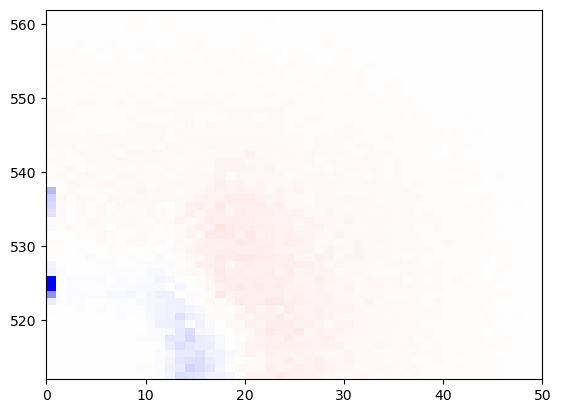

(512.0, 562.0)

In [11]:

pv = fftshift(grid.Krsq,2) .* r3

plt.pcolormesh((pv)', vmin=-0.25*maximum(abs.(pv)), vmax=0.25*maximum(abs.(pv)), cmap =PyPlot.cm.bwr)

plt.xlim(0,50)
plt.ylim(512,562)

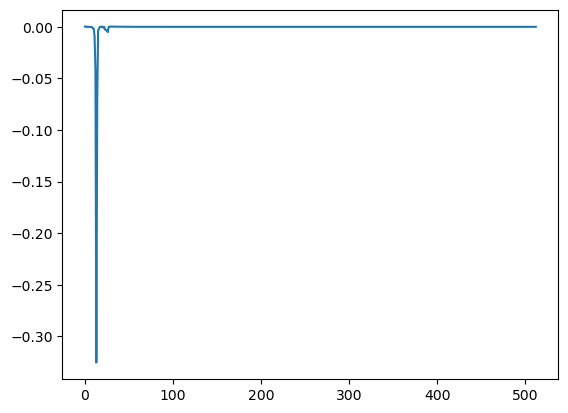

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x147780159c30>

In [14]:
plt.plot(r3[1,512:end])

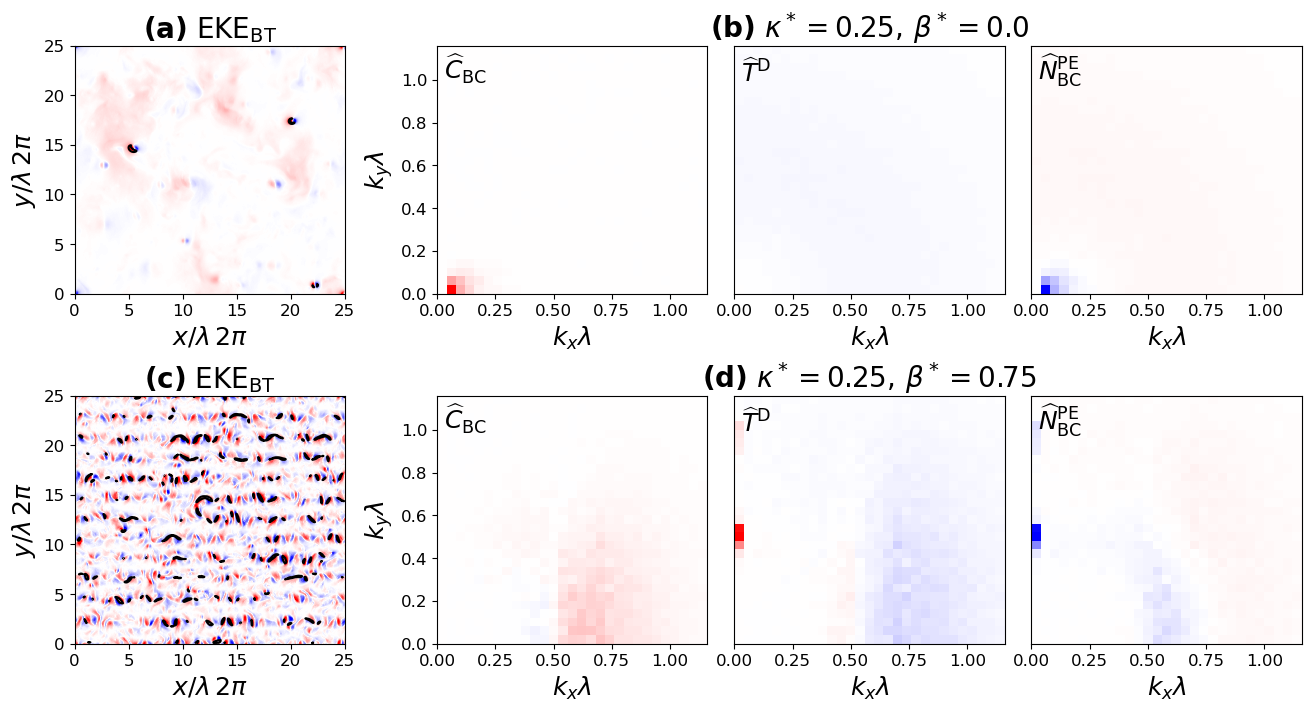

PyObject Text(395.41388888888923, 0.5, '$k_{y} \\lambda $')

In [55]:

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = betas[7]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name_2L(model_params,71.95))


###################################################################################
###################################################################################
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subfigures.html
fig, axs = plt.subplots(2, 4, layout="constrained", figsize=(13, 7)) # , width_ratios = [1.2,1.,1.,1.])
gridspec = axs[1, 1].get_subplotspec().get_gridspec()



# clear the left column for the subfigure:
# for a in axs[:, 1]
#     a.remove()
# end

###########################################################################
############################################################################
# fig, ax = plt.subplots(1,3, figsize=(10,3))
# fig.tight_layout(pad=-2.0)

ax1=axs[1,2]; ax2=axs[1,3]; ax3=axs[1,4];

tsize = 20
fsize = 18
lsize = 12

x = prob.grid.kr .* Ld
y = prob.grid.l .* Ld

x = append!(x[:,1], [x[end] + x[end] - x[end-1]])
# y = append!(y[1,:], [y[end] + y[end] - y[end-1]])

y = fftshift(y)
y = append!(y[1,:], [20.48])

lim_range = 30

lim = 1.0 * maximum([abs.(sqrt.(grid.Krsq) .* a["jld_data"]["CBC"]); abs.(sqrt.(grid.Krsq) .* a["jld_data"]["T_D"]); abs.(sqrt.(grid.Krsq) .* a["jld_data"]["NL_BC_EAPE"])])

lim1 = lim2 = lim3 = lim
########################################################################################################

# lim1 = maximum(abs.(a["jld_data"]["CBC"]))

pc1 = ax1.pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* a["jld_data"]["CBC"],2)', vmin=-lim1, vmax=lim1, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc1.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax1.set_xlim(x[1],x[lim_range])
ax1.set_ylim(0,y[512+lim_range])

# PyPlot.subplots_adjust(wspace=0, hspace=0)


########################################################################################################

# lim2 = maximum(abs.(a["jld_data"]["T_D"]))

pc2 = ax2.pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* a["jld_data"]["T_D"],2)', vmin=-lim2, vmax=lim2, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc2.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax2.set_xlim(x[1],x[lim_range])
ax2.set_ylim(0,y[512+lim_range])

########################################################################################################

# lim3 = maximum(abs.(a["jld_data"]["NL_BC_EAPE"]))

pc3 = ax3.pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* a["jld_data"]["NL_BC_EAPE"],2)', vmin=-lim3, vmax=lim3, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc3.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax3.set_xlim(x[1],x[lim_range])
ax3.set_ylim(0,y[512+lim_range])

########################################################################################################

ax2.set_yticks([])
ax3.set_yticks([])

ax2.set_title(L"\mathbf{(b)} \ \kappa^* = 0.25, \, \beta^* = 0.0", fontsize=tsize)

ax1.text(0.025, 0.975, L"\widehat{C}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax1.transAxes);
ax2.text(0.025, 0.95, L"\widehat{T}^\mathrm{D}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax2.transAxes);
ax3.text(0.025, 0.975, L"\widehat{N}^\mathrm{PE}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax3.transAxes);

# ax1.grid()
# ax2.grid()
# ax3.grid()


############################################################################
###########################################################################
# make the subfigure in the empty gridspec slots:

subfig = fig.add_subfigure(gridspec[1, 1])

axul = axs[1,1] # subfig.subplots(1, 1)

plot_zetaBT(a, prob, axul)

axul.set_title(L"\mathbf{(a)} \ \mathrm{EKE}_\mathrm{BT}", fontsize=tsize)


############################################################################
###########################################################################

beta = betas[10]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name_2L(model_params,71.95))

ax1=axs[2,2]; ax2=axs[2,3]; ax3=axs[2,4];

lim = 0.25 * maximum([abs.(sqrt.(grid.Krsq) .* a["jld_data"]["CBC"]); abs.(sqrt.(grid.Krsq) .* a["jld_data"]["T_D"]); abs.(sqrt.(grid.Krsq) .* a["jld_data"]["NL_BC_EAPE"])])

lim1 = lim2 = lim3 = lim
########################################################################################################

# lim1 = maximum(abs.(a["jld_data"]["CBC"]))

pc1 = ax1.pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* a["jld_data"]["CBC"],2)', vmin=-lim1, vmax=lim1, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc1.set_edgecolor("face")

ax1.set_xlim(x[1],x[lim_range])
ax1.set_ylim(0,y[512+lim_range])

########################################################################################################

# lim2 = maximum(abs.(a["jld_data"]["T_D"]))

pc2 = ax2.pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* a["jld_data"]["T_D"],2)', vmin=-lim2, vmax=lim2, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc2.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax2.set_xlim(x[1],x[lim_range])
ax2.set_ylim(0,y[512+lim_range])

########################################################################################################

# lim3 = maximum(abs.(a["jld_data"]["NL_BC_EAPE"]))

pc3 = ax3.pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* a["jld_data"]["NL_BC_EAPE"],2)', vmin=-lim3, vmax=lim3, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc3.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax3.set_xlim(x[1],x[lim_range])
ax3.set_ylim(0,y[512+lim_range])

########################################################################################################

ax2.set_yticks([])
ax3.set_yticks([])

ax2.set_title(L"\mathbf{(d)} \ \kappa^* = 0.25, \, \beta^* = 0.75", fontsize=tsize)

ax1.text(0.025, 0.975, L"\widehat{C}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax1.transAxes);
ax2.text(0.025, 0.95, L"\widehat{T}^\mathrm{D}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax2.transAxes);
ax3.text(0.025, 0.975, L"\widehat{N}^\mathrm{PE}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax3.transAxes);

# ax1.grid()
# ax2.grid()
# ax3.grid()



############################################################################
###########################################################################

subfig = fig.add_subfigure(gridspec[2, 1])

axll = axs[2,1] #subfig.subplots(1, 1)

plot_zetaBT(a, prob, axll)

axll.set_title(L"\mathbf{(c)} \ \mathrm{EKE}_\mathrm{BT}", fontsize=tsize)


############################################################################
###########################################################################
# make the subfigure in the empty gridspec slots:



# for axn in ax[4:end]
#     axn.set_yticklabels([])
# end
# for axn in [ax[1:2]; ax[4:5]; ax[7:8]]
#     axn.set_xticklabels([])
# end

axs[1,2].tick_params(labelsize=lsize)
axs[1,3].tick_params(labelsize=lsize)
axs[1,4].tick_params(labelsize=lsize)
axs[2,2].tick_params(labelsize=lsize)
axs[2,3].tick_params(labelsize=lsize)
axs[2,4].tick_params(labelsize=lsize)

axll.tick_params(labelsize=lsize)
axul.tick_params(labelsize=lsize)

axul.set_ylabel(L"y / \lambda \, 2 \pi ", fontsize=fsize)
axll.set_ylabel(L"y / \lambda \, 2 \pi", fontsize=fsize)

axul.set_xlabel(L"x / \lambda \, 2 \pi ", fontsize=fsize)
axll.set_xlabel(L"x / \lambda \, 2 \pi ", fontsize=fsize)

axs[1,2].set_xlabel(L"k_{x} \lambda ", fontsize=fsize)
axs[1,3].set_xlabel(L"k_{x} \lambda ", fontsize=fsize)
axs[1,4].set_xlabel(L"k_{x} \lambda ", fontsize=fsize)
axs[2,2].set_xlabel(L"k_{x} \lambda ", fontsize=fsize)
axs[2,3].set_xlabel(L"k_{x} \lambda ", fontsize=fsize)
axs[2,4].set_xlabel(L"k_{x} \lambda ", fontsize=fsize)


axs[1,2].set_ylabel(L"k_{y} \lambda ", fontsize=fsize)
axs[2,2].set_ylabel(L"k_{y} \lambda ", fontsize=fsize)

# subfig.set_facecolor('0.75')
# for ax in axsLeft:
#     pc = example_plot(ax)
# subfig.suptitle('Left plots', fontsize='x-large')
# subfig.colorbar(pc, shrink=0.6, ax=axsLeft, location='bottom')

# fig.suptitle('Figure suptitle', fontsize='xx-large')
# plt.show()


# savefig("./JFM_BC_nrg_figs/zetaBT_2Dspectra.pdf",bbox_inches="tight")


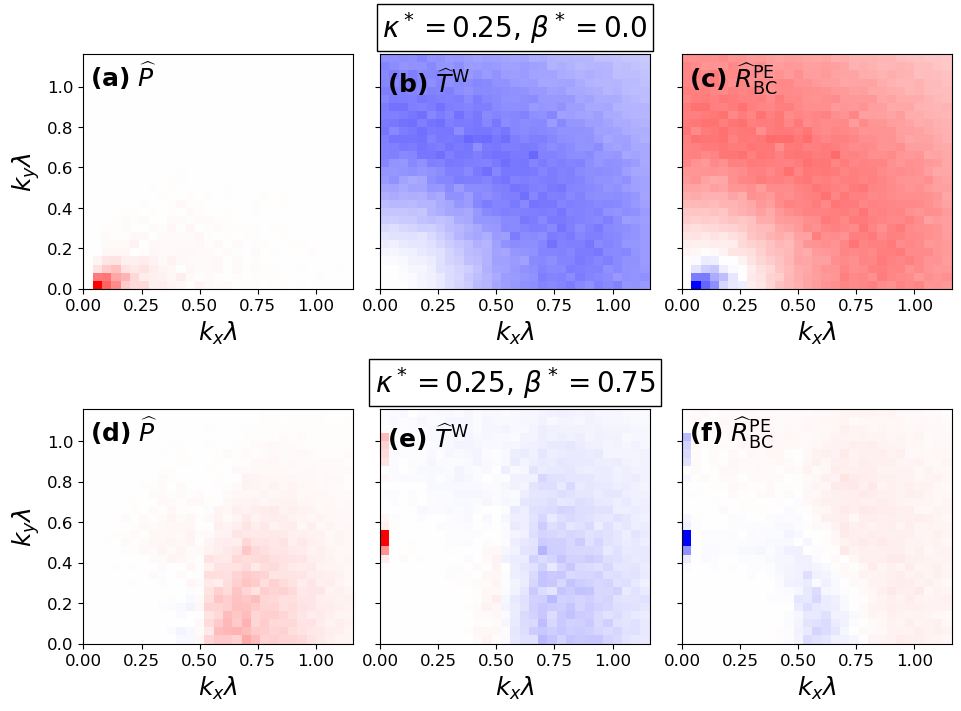

In [41]:

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = betas[7]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name_2L(model_params,71.95))


###################################################################################
###################################################################################
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subfigures.html
fig, ax = plt.subplots(3, 3, layout="constrained", figsize=(9.5, 7), height_ratios=[1., 0.005, 1.]) # , width_ratios = [1.2,1.,1.,1.])

ax1=ax[1]; ax2=ax[4]; ax3=ax[7];
ax[2].axis("off");
ax[5].axis("off");
ax[8].axis("off");
ax4=ax[3]; ax5=ax[6]; ax6=ax[9];

# clear the left column for the subfigure:
# for a in axs[:, 1]
#     a.remove()
# end

###########################################################################
############################################################################
# fig, ax = plt.subplots(1,3, figsize=(10,3))
# fig.tight_layout(pad=-2.0)

tsize = 20
fsize = 18
lsize = 12

x = prob.grid.kr .* Ld
y = prob.grid.l .* Ld

x = append!(x[:,1], [x[end] + x[end] - x[end-1]])
# y = append!(y[1,:], [y[end] + y[end] - y[end-1]])

y = fftshift(y)
y = append!(y[1,:], [20.48])

lim_range = 30

lim = 1.0 * maximum([abs.(grid.Krsq .* a["jld_data"]["CBC"]); abs.(grid.Krsq .* a["jld_data"]["T_D"]); abs.(grid.Krsq .* a["jld_data"]["NL_BC_EAPE"])])

lim1 = lim2 = lim3 = lim
########################################################################################################

# lim1 = maximum(abs.(a["jld_data"]["CBC"]))

pc1 = ax1.pcolormesh(x, y, fftshift(grid.Krsq .* a["jld_data"]["CBC"],2)', vmin=-lim1, vmax=lim1, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc1.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax1.set_xlim(x[1],x[lim_range])
ax1.set_ylim(0,y[512+lim_range])

# PyPlot.subplots_adjust(wspace=0, hspace=0)

########################################################################################################

# lim2 = maximum(abs.(a["jld_data"]["T_D"]))

pc2 = ax2.pcolormesh(x, y, fftshift(grid.Krsq .* a["jld_data"]["T_D"],2)', vmin=-lim2, vmax=lim2, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc2.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax2.set_xlim(x[1],x[lim_range])
ax2.set_ylim(0,y[512+lim_range])

########################################################################################################

# lim3 = maximum(abs.(a["jld_data"]["NL_BC_EAPE"]))

pc3 = ax3.pcolormesh(x, y, fftshift(grid.Krsq .* a["jld_data"]["NL_BC_EAPE"],2)', vmin=-lim3, vmax=lim3, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc3.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax3.set_xlim(x[1],x[lim_range])
ax3.set_ylim(0,y[512+lim_range])

########################################################################################################

ax2.set_yticklabels([])
ax3.set_yticklabels([])


ax1.text(0.025, 0.975, L"\mathbf{(a)} \ \widehat{P}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax1.transAxes);
ax2.text(0.025, 0.95, L"\mathbf{(b)} \ \widehat{T}^\mathrm{W}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax2.transAxes);
ax3.text(0.025, 0.975, L"\mathbf{(c)} \ \widehat{R}^\mathrm{PE}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax3.transAxes);

# ax1.grid()
# ax2.grid()
# ax3.grid()

ax2.text(0.5, 1.115, L"\kappa^* = 0.25, \, \beta^* = 0.0", fontsize=tsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes,
    bbox=Dict("facecolor"=>"none", "edgecolor"=>"black"));



############################################################################
###########################################################################

beta = betas[10]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name_2L(model_params,71.95))


lim = 0.25 * maximum([abs.(grid.Krsq .* a["jld_data"]["CBC"]); abs.(grid.Krsq .* a["jld_data"]["T_D"]); abs.(grid.Krsq .* a["jld_data"]["NL_BC_EAPE"])])

lim1 = lim2 = lim3 = lim
########################################################################################################

# lim1 = maximum(abs.(a["jld_data"]["CBC"]))

pc4 = ax4.pcolormesh(x, y, fftshift(grid.Krsq .* a["jld_data"]["CBC"],2)', vmin=-lim1, vmax=lim1, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc4.set_edgecolor("face")

ax4.set_xlim(x[1],x[lim_range])
ax4.set_ylim(0,y[512+lim_range])

########################################################################################################

# lim2 = maximum(abs.(a["jld_data"]["T_D"]))

pc5 = ax5.pcolormesh(x, y, fftshift(grid.Krsq .* a["jld_data"]["T_D"], 2)', vmin=-lim2, vmax=lim2, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc5.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax5.set_xlim(x[1],x[lim_range])
ax5.set_ylim(0,y[512+lim_range])

########################################################################################################

# lim3 = maximum(abs.(a["jld_data"]["NL_BC_EAPE"]))

pc6 = ax6.pcolormesh(x, y, fftshift(grid.Krsq .* a["jld_data"]["NL_BC_EAPE"],2)', vmin=-lim3, vmax=lim3, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc6.set_edgecolor("face")
# plt.colorbar(pc1, location="bottom")

ax6.set_xlim(x[1],x[lim_range])
ax6.set_ylim(0,y[512+lim_range])

########################################################################################################

ax5.set_yticklabels([])
ax6.set_yticklabels([])

ax5.text(0.5, 1.115, L" \kappa^* = 0.25, \, \beta^* = 0.75", fontsize=tsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes,
    bbox=Dict("facecolor"=>"none", "edgecolor"=>"black"));

ax4.text(0.025, 0.975, L"\mathbf{(d)} \ \widehat{P}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax4.transAxes);
ax5.text(0.025, 0.95, L"\mathbf{(e)} \ \widehat{T}^\mathrm{W}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax5.transAxes);
ax6.text(0.025, 0.975, L"\mathbf{(f)} \ \widehat{R}^\mathrm{PE}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax6.transAxes);

# ax1.grid()
# ax2.grid()
# ax3.grid()





############################################################################
###########################################################################
# make the subfigure in the empty gridspec slots:



# for axn in ax[4:end]
#     axn.set_yticklabels([])
# end
# for axn in [ax[1:2]; ax[4:5]; ax[7:8]]
#     axn.set_xticklabels([])
# end

for axn in ax
    axn.tick_params(labelsize=lsize)
    axn.set_xlabel(L"k_{x} \lambda ", fontsize=fsize)
end

ax1.set_ylabel(L"k_{y} \lambda ", fontsize=fsize)
ax4.set_ylabel(L"k_{y} \lambda ", fontsize=fsize)

# subfig.set_facecolor('0.75')
# for ax in axsLeft:
#     pc = example_plot(ax)
# subfig.suptitle('Left plots', fontsize='x-large')
# subfig.colorbar(pc, shrink=0.6, ax=axsLeft, location='bottom')

# fig.suptitle('Figure suptitle', fontsize='xx-large')
# plt.show()


savefig("./JFM_BC_nrg_figs/2Dspectra.pdf",bbox_inches="tight")



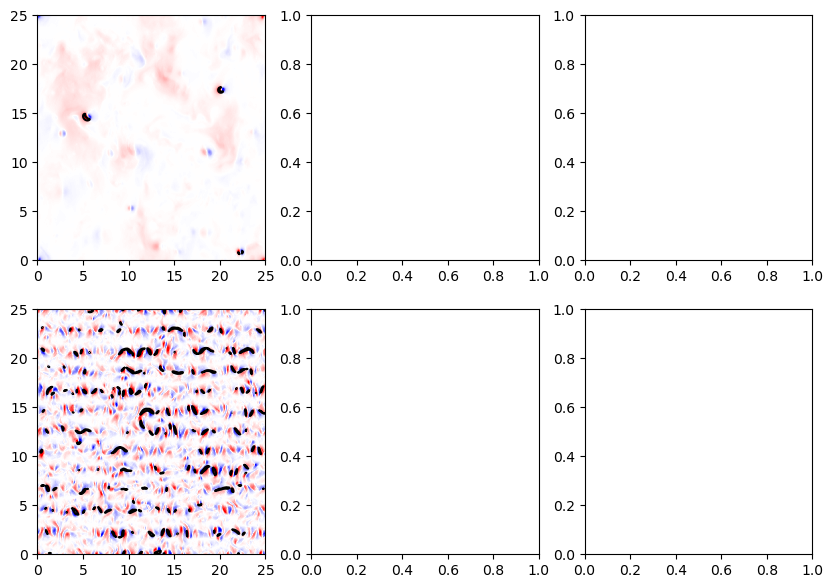

PyObject <matplotlib.contour.QuadContourSet object at 0x153e9b3299f0>

In [43]:

function plot_domain_corner(a, prob, ax, var_str)
    ψ = a["jld_data"]["psi_yrs_end"]
    
    grid = prob.grid
            
    # assigning basic variables
    ψBC = 0.5 * (ψ[:,:,1] .- ψ[:,:,2])
    ψBT = 0.5 * (ψ[:,:,1] .+ ψ[:,:,2])
    
    ψBCh = deepcopy(vars.uh[:,:,1])
    ψBTh = deepcopy(vars.uh[:,:,1])
    
    mul2D!(ψBCh, rfftplan, ψBC)
    mul2D!(ψBTh, rfftplan, ψBT)
    
    ζBCh = - sqrt.(grid.Krsq) .* ψBCh
    ζBTh = -im .* grid.l .* ψBTh  # - sqrt.(grid.Krsq) .* ψBTh
    
    ζBC = deepcopy(vars.u[:,:,1])
    ζBT = deepcopy(vars.u[:,:,1])
    
    ldiv2D!(ζBC, rfftplan, ζBCh)
    ldiv2D!(ζBT, rfftplan, ζBTh)

    ##
    ∂xψBTh = im * grid.kr .* ψBTh
    ∂yψBTh = im * grid.l .* ψBTh
    
    ∂xψBT = deepcopy(vars.u[:,:,1])
    ∂yψBT = deepcopy(vars.u[:,:,1])

    ldiv2D!(∂xψBT, rfftplan, im * grid.kr .* ψBTh)
    ldiv2D!(∂yψBT, rfftplan, im * grid.l .* ψBTh)

    ∂xψBCh = im * grid.kr .* ψBCh
    ∂yψBCh = im * grid.l .* ψBCh

    ∂xψBC = deepcopy(vars.u[:,:,1])
    ∂yψBC = deepcopy(vars.u[:,:,1])

    ldiv2D!(∂xψBC, rfftplan, im * grid.kr .* ψBCh)
    ldiv2D!(∂yψBC, rfftplan, im * grid.l .* ψBCh)

    EKE_xy = @. ∂xψBT^2 + ∂yψBT^2 

    CBC = ∂xψBT .* ψBC
    ##
    
    norm = (a["jld_data"]["two_layer_vBT_scale"])^-2
    EKE_lim = maximum(abs.(EKE_xy))
    CBC_lim = maximum(abs.(CBC .* norm))/2

    x = collect(range(0, Lx, 1025)) ./ (Ld * 2 * pi)
    y = collect(range(0, Lx, 1025)) ./ (Ld * 2 * pi)

    xm = collect(range(0, Lx, 1024)) ./ (Ld * 2 * pi)
    ym = collect(range(0, Lx, 1024)) ./ (Ld * 2 * pi)
    
    ax.pcolormesh(x, y, (CBC .* norm)', cmap=PyPlot.cm.bwr, vmin=-CBC_lim, vmax=CBC_lim, rasterized=true)

    ax.contour(xm, ym, EKE_xy', colors="black", levels=[0.5*EKE_lim])
    
end

############################################################################
###########################################################################


i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = betas[7]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name_2L(model_params,71.95))

############################################################################
###########################################################################


fig, ax = plt.subplots(2,3, figsize=(10,7))
ax1=ax[1]; ax2=ax[3]; ax3=ax[5];
ax4=ax[2]; ax5=ax[4]; ax6=ax[6];

############################################################################
###########################################################################

plot_domain_corner(a, prob, ax1, "EKE")

############################################################################
###########################################################################


beta = betas[10]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name_2L(model_params,71.95))


plot_domain_corner(a, prob, ax4, "EKE")

# for axn in ax
#     axn.set_xlim(12.5, 25)
#     axn.set_ylim(0, 12.5)
# end



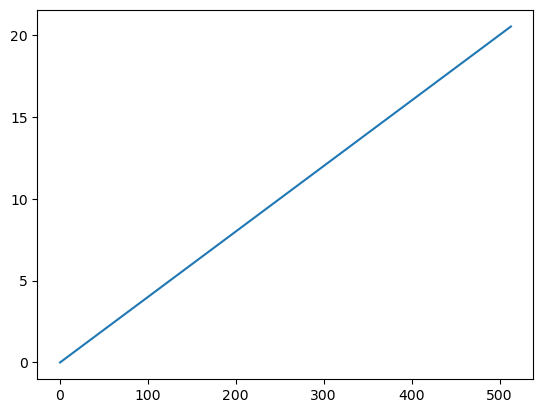

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x153f5c151810>

In [23]:
# plt.pcolormesh(grid.Krsq')

plt.plot(x)

# plt.xlim(0,25)
# plt.ylim(0,25)

In [63]:
println(sum(grid.kr .*  a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10]))  #NL BT EKE cons.

println(sum(grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11]))  #NL BT EKE trans.


-0.0001246294571468129
0.002039579537004438


In [62]:
println(sum( a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,10]))  #NL BT EKE cons.

println(sum( a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,11]))  #NL BT EKE trans.


359.93368689539335
227.80802733353306


In [57]:
println(sum(grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,5])) # CBC

println(sum(grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,14]))  #NL EAPE


println(sum(grid.kr .* a["jld_data"]["two_layer_kspace_modal_nrg_budget"][:,4]))  # TD

0.0014837734325631106
0.0006201728688244745
-0.0021008629657813483


In [30]:
# coherence plot for kappa*=4.0, beta* = 0.

tsize = 16
fsize = 16
lsize = 11

x = prob.grid.kr .* Ld

############################################################################################
# strong-drag f-plane
############################################################################################

mu_loc = mus[6]
beta = betas[7]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, 0., (0., 0.), (0., 0.))
global model_params = redef_mu_kappa_beta(model_params, mu_loc, 0., beta)

a = load(data_dir*jld_name(model_params,71.95))

#####################

ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{D})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax7.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \,  \widehat{T}^\mathrm{D})", linewidth=2.0)

############################################################################################

ax7.set_xlim(x[2], 1.5)

ax7.set_ylim(0., 1.)

ax7.legend(loc="upper right", fontsize = lsize, ncols=2)

ax7.grid()

ax7.set_xlabel(L"|\boldsymbol{k}| \, \lambda", fontsize = fsize)


ax7.set_ylabel(L"\mathrm{Coherence}", fontsize = fsize)

ax7.tick_params(axis="both", labelsize=lsize)

############################################################################################

ax7.set_title(L"\mathbf{(g)} \ \kappa^* = 4.0, \, \beta^* = 0.0", fontsize=tsize)

############################################################################################



1.5928327482310865e-5 + 0.0im

In [123]:
a["jld_data"]

Dict{String, Any} with 14 entries:
  "ph_slices"                         => 0.843444
  "two_layer_modal_length_scales"     => [2.03961e-5; 2.12341e-5;;]
  "ph_iso"                            => 0.600458
  "two_layer_xspace_modal_nrg_budget" => [0.000109884; 9.64196e-5; … ; 6.21333e…
  "coh_DBC_TD"                        => [NaN 3.12705e-5 … 1.37586e-5 3.12705e-…
  "psi_yrs_end"                       => [-1040.33 -1094.07 … -947.292 -983.35;…
  "two_layer_kspace_modal_nrg_budget" => [0.0 0.0 … 0.0 2.72461e-35; 544.049 59…
  "t"                                 => [1.70411e9, 1.70411e9, 1.70417e9, 1.70…
  "two_layer_xspace_nrgs_ot"          => [0.000400259 0.000400259 … 0.0 0.0; 1.…
  "coh_DBC_NLBC2BT"                   => [NaN 2.9157e-5 … 1.91358e-5 2.9157e-5;…
  "two_layer_vBT_scale"               => 0.0148246
  "NL_BC_EAPE"                        => [0.0 0.00271357 … 0.00378401 0.0027135…
  "coh_NLBCEKE_NLBC2BT"               => [NaN 2.98322e-5 … 3.04591e-5 2.98322e-…
  "coh_NLBCEKE_TD

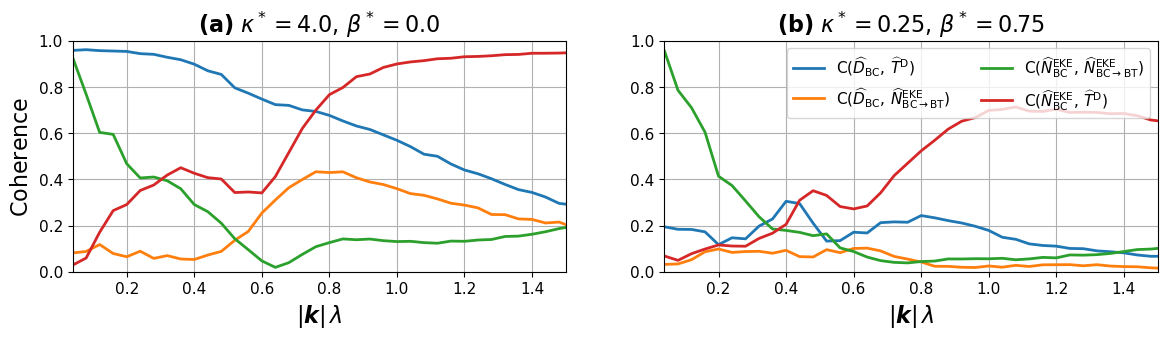

In [32]:
# coherence plot for kappa*=4.0, beta* = 0.

fig, ax = plt.subplots(1, 2, figsize=(14,3))
ax1=ax[1]; ax2=ax[2];

tsize = 16
fsize = 16
lsize = 11

x = prob.grid.kr .* Ld

############################################################################################
# strong-drag f-plane
############################################################################################

mu_loc = mus[6]
beta = betas[7]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, 0., (0., 0.), (0., 0.))
global model_params = redef_mu_kappa_beta(model_params, mu_loc, 0., beta)

a = load(data_dir*jld_name(model_params,71.95))

#####################
#####################

ax1.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{D})", linewidth=2.0)
ax1.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax1.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax1.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \,  \widehat{T}^\mathrm{D})", linewidth=2.0)



############################################################################################
# weak-drag beta-plane
############################################################################################

mu_loc = mus[2]
beta = betas[10]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, 0., (0., 0.), (0., 0.))
global model_params = redef_mu_kappa_beta(model_params, mu_loc, 0., beta)

a = load(data_dir*jld_name(model_params,71.95))

#####################
#####################


ax2.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{D})", linewidth=2.0)
ax2.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax2.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax2.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \,  \widehat{T}^\mathrm{D})", linewidth=2.0)





############################################################################################
############################################################################################






############################################################################################
############################################################################################




############################################################################################
############################################################################################

ax1.set_xlim(x[2], 1.5)
ax2.set_xlim(x[2], 1.5)

ax1.set_ylim(0., 1.)
ax2.set_ylim(0., 1.)

ax2.legend(loc="upper right", fontsize = lsize, ncols=2)

ax1.grid()
ax2.grid()

ax1.set_xlabel(L"|\boldsymbol{k}| \, \lambda", fontsize = fsize)
ax2.set_xlabel(L"|\boldsymbol{k}| \, \lambda", fontsize = fsize)


ax1.set_ylabel(L"\mathrm{Coherence}", fontsize = fsize)

ax1.tick_params(axis="both", labelsize=lsize)
ax2.tick_params(axis="both", labelsize=lsize)

############################################################################################
############################################################################################

# ax1.text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
# ax2.text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);

ax1.set_title(L"\mathbf{(a)} \ \kappa^* = 4.0, \, \beta^* = 0.0", fontsize=tsize)
ax2.set_title(L"\mathbf{(b)} \ \kappa^* = 0.25, \, \beta^* = 0.75", fontsize=tsize)

############################################################################################
############################################################################################

savefig("./JFM_BC_nrg_figs/coherence.pdf",bbox_inches="tight")


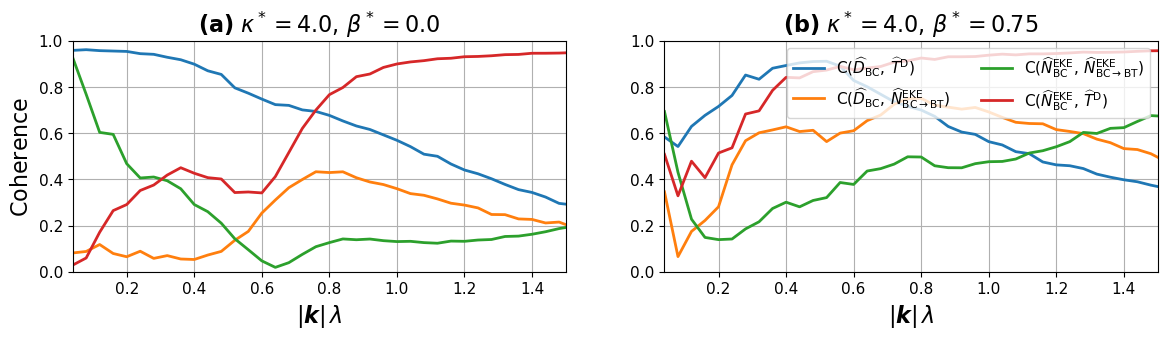

PyObject Text(0.5, 1.0, '$\\mathbf{(b)} \\ \\kappa^* = 4.0, \\, \\beta^* = 0.75$')

In [8]:
# coherence plot for kappa*=4.0, beta* = 0.

fig, ax = plt.subplots(1, 2, figsize=(14,3))
ax1=ax[1]; ax2=ax[2];

tsize = 16
fsize = 16
lsize = 11

x = prob.grid.kr .* Ld

############################################################################################
# strong-drag f-plane
############################################################################################

mu_loc = mus[6]
beta = betas[7]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, 0., (0., 0.), (0., 0.))
global model_params = redef_mu_kappa_beta(model_params, mu_loc, 0., beta)

a = load(data_dir*jld_name(model_params,71.95))

#####################
#####################

ax1.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{D})", linewidth=2.0)
ax1.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax1.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax1.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \,  \widehat{T}^\mathrm{D})", linewidth=2.0)



############################################################################################
# weak-drag beta-plane
############################################################################################

mu_loc = mus[6]
beta = betas[10]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, 0., (0., 0.), (0., 0.))
global model_params = redef_mu_kappa_beta(model_params, mu_loc, 0., beta)

a = load(data_dir*jld_name(model_params,71.95))

#####################
#####################


ax2.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{D})", linewidth=2.0)
ax2.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax2.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \, \widehat{N}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
ax2.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{N}_\mathrm{BC}^\mathrm{EKE}, \,  \widehat{T}^\mathrm{D})", linewidth=2.0)





############################################################################################
############################################################################################






############################################################################################
############################################################################################




############################################################################################
############################################################################################

ax1.set_xlim(x[2], 1.5)
ax2.set_xlim(x[2], 1.5)

ax1.set_ylim(0., 1.)
ax2.set_ylim(0., 1.)

ax2.legend(loc="upper right", fontsize = lsize, ncols=2)

ax1.grid()
ax2.grid()

ax1.set_xlabel(L"|\boldsymbol{k}| \, \lambda", fontsize = fsize)
ax2.set_xlabel(L"|\boldsymbol{k}| \, \lambda", fontsize = fsize)


ax1.set_ylabel(L"\mathrm{Coherence}", fontsize = fsize)

ax1.tick_params(axis="both", labelsize=lsize)
ax2.tick_params(axis="both", labelsize=lsize)

############################################################################################
############################################################################################

# ax1.text(0.075, 0.9, L"\mathbf{(a)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax1.transAxes);
# ax2.text(0.075, 0.9, L"\mathbf{(b)}", fontsize=fsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes);

ax1.set_title(L"\mathbf{(a)} \ \kappa^* = 4.0, \, \beta^* = 0.0", fontsize=tsize)
ax2.set_title(L"\mathbf{(b)} \ \kappa^* = 4.0, \, \beta^* = 0.75", fontsize=tsize)

############################################################################################
############################################################################################

# savefig("./JFM_BC_nrg_figs/coherence.pdf",bbox_inches="tight")


In [52]:

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = betas[7]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)


# a = load(alt_data_dir*jld_name(model_params,71.99))
a = load(alt_data_dir*jld_name(model_params,71.95))

    

Dict{String, Any} with 1 entry:
  "jld_data" => Dict{String, Any}("ph_slices"=>0.031725, "two_layer_modal_lengt…

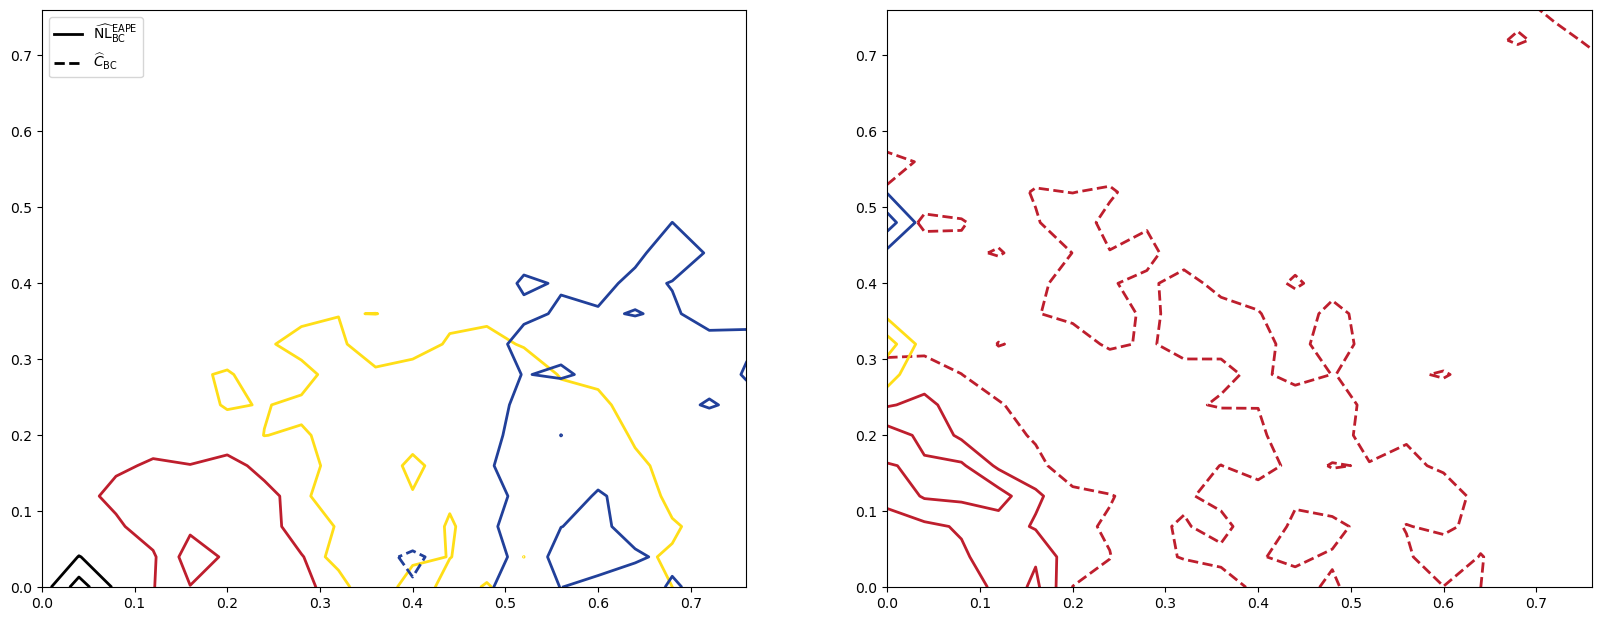

(0.0, 0.76)

In [76]:
fig, ax = plt.subplots(1,2, figsize=(20,7.5))
ax1=ax[1]; ax2=ax[2];

beta_cont = [betas[7], betas[8], betas[9], betas[10]]
Bauhaus_colors = ["#000000", "#be1e2d", "#ffde17", "#21409a"]

x = prob.grid.kr .* Ld
y = prob.grid.l .* Ld

xv = first.(Iterators.product(x,y))[:,1,1,:]
yv = last.(Iterators.product(x,y))[:,1,1,:]

labels = []
custom_lines = []

mu_loc = mus[2]

for (i, b) in enumerate(beta_cont)
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, b)

    a = load(alt_data_dir*jld_name(model_params,71.95))

    ac = ax1.contour(xv, yv, a["jld_data"]["CBC"] ./ maximum(a["jld_data"]["CBC"]), colors=Bauhaus_colors[i], levels=[-0.75, -0.25, 0.25, 0.75], linewidths=2.0)
    ax2.contour(xv, yv,  a["jld_data"]["T_D"] ./ maximum(a["jld_data"]["T_D"]), colors=Bauhaus_colors[i], levels=[-0.75, -0.25, 0.25, 0.75], linewidths=2.0)
    # ax2.contour(xv, yv,  a["jld_data"]["NL_BC_EAPE"] ./ maximum(a["jld_data"]["NL_BC_EAPE"]), colors=Bauhaus_colors[i], levels=[-0.75, -0.25, 0.25, 0.75], linewidths=2.0)

    ax1.clabel(ac, inline=1, fontsize=14)

    labels = [labels; L"\beta = "*string(round(b * 2 * Ld^2 / U[1],digits=3))]
    custom_lines = [custom_lines; matplotlib.lines.Line2D([0], [0], color=Bauhaus_colors[i], lw=2.0)]

end

########################################
## legend
########################################

# legend for beta values
legend1 = ax1.legend(custom_lines, labels, loc="upper right")

# legend for two variables plotted
ax1.legend([matplotlib.lines.Line2D([0], [0], color="black", linestyle="solid", lw=2.0), matplotlib.lines.Line2D([0], [0], color="black", linestyle="dashed", lw=2.0)], [L"\widehat{\mathrm{NL}}_\mathrm{BC}^\mathrm{EAPE}", L"\widehat{C}_\mathrm{BC}"], loc="upper left")

# PyPlot.gca().add_artist(legend1)
########################################
## legend end
########################################


ax1.set_xlim(x[1], x[20])
ax1.set_ylim(y[1], y[20])

ax2.set_xlim(x[1], x[20])
ax2.set_ylim(y[1], y[20])

# note that plotted values are positive



In [41]:

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = betas[7]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)


# a = load(alt_data_dir*jld_name(model_params,71.99))
a = load(alt_data_dir*jld_name(model_params,71.95))

    

Dict{String, Any} with 1 entry:
  "jld_data" => Dict{String, Any}("ph_slices"=>0.031725, "two_layer_modal_lengt…

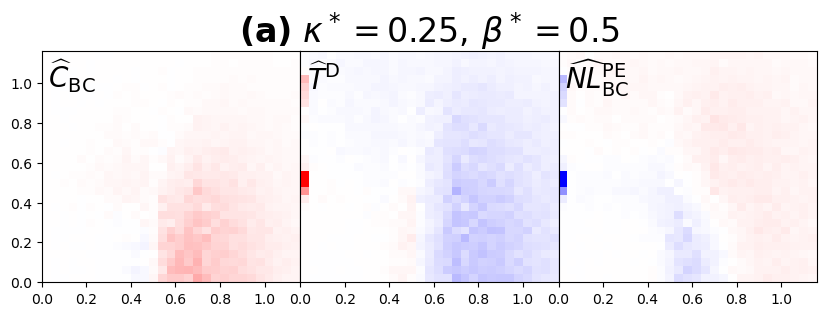

In [104]:
fig, ax = plt.subplots(1,3, figsize=(10,3))
# fig.tight_layout(pad=-2.0)

ax1=ax[1]; ax2=ax[2]; ax3=ax[3];

tsize = 24
fsize = 20

x = prob.grid.kr .* Ld
y = prob.grid.l .* Ld

x = append!(x[:,1], [x[end] + x[end] - x[end-1]])
# y = append!(y[1,:], [y[end] + y[end] - y[end-1]])

y = fftshift(y)
y = append!(y[1,:], [20.48])

lim_range = 30

lim = 0.25 * maximum([abs.(sqrt.(grid.Krsq) .* a["jld_data"]["CBC"]); abs.(sqrt.(grid.Krsq) .* a["jld_data"]["T_D"]); abs.(sqrt.(grid.Krsq) .* a["jld_data"]["NL_BC_EAPE"])])

lim1 = lim2 = lim3 = lim
########################################################################################################
########################################################################################################

# lim1 = maximum(abs.(a["jld_data"]["CBC"]))

pc1 = ax1.pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* a["jld_data"]["CBC"],2)', vmin=-lim1, vmax=lim1, cmap = PyPlot.cm.bwr)
# plt.colorbar(pc1, location="bottom")

ax1.set_xlim(x[1],x[lim_range])
ax1.set_ylim(0,y[512+lim_range])



########################################################################################################
########################################################################################################

# lim2 = maximum(abs.(a["jld_data"]["T_D"]))

pc2 = ax2.pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* a["jld_data"]["T_D"],2)', vmin=-lim2, vmax=lim2, cmap = PyPlot.cm.bwr)
# plt.colorbar(pc1, location="bottom")

ax2.set_xlim(x[1],x[lim_range])
ax2.set_ylim(0,y[512+lim_range])




########################################################################################################
########################################################################################################

# lim3 = maximum(abs.(a["jld_data"]["NL_BC_EAPE"]))

pc3 = ax3.pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* a["jld_data"]["NL_BC_EAPE"],2)', vmin=-lim3, vmax=lim3, cmap = PyPlot.cm.bwr)
# plt.colorbar(pc1, location="bottom")

ax3.set_xlim(x[1],x[lim_range])
ax3.set_ylim(0,y[512+lim_range])





########################################################################################################
########################################################################################################

ax2.set_yticks([])
ax3.set_yticks([])

ax2.set_title(L"\mathbf{(a)} \ \kappa^* = 0.25, \, \beta^* = 0.5", fontsize=tsize)

ax1.text(0.025, 0.975, L"\widehat{C}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax1.transAxes);
ax2.text(0.025, 0.95, L"\widehat{T}^\mathrm{D}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax2.transAxes);
ax3.text(0.025, 0.975, L"\widehat{NL}^\mathrm{PE}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax3.transAxes);

# ax1.grid()
# ax2.grid()
# ax3.grid()

plt.subplots_adjust(wspace=0, hspace=0)



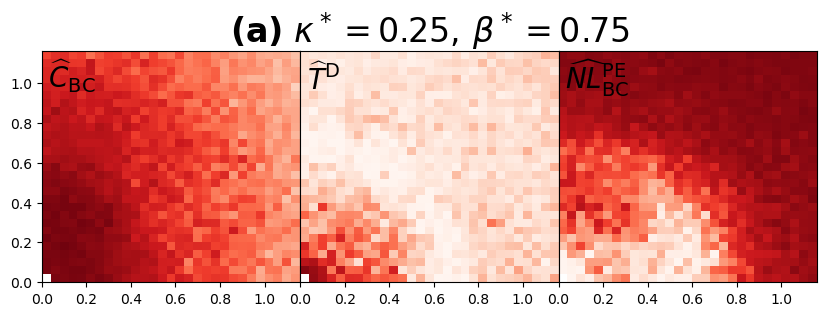

In [34]:
fig, ax = plt.subplots(1,3, figsize=(10,3))
# fig.tight_layout(pad=-2.0)

ax1=ax[1]; ax2=ax[2]; ax3=ax[3];

tsize = 24
fsize = 20

x = prob.grid.kr .* Ld
y = prob.grid.l .* Ld

x = append!(x[:,1], [x[end] + x[end] - x[end-1]])
# y = append!(y[1,:], [y[end] + y[end] - y[end-1]])

y = fftshift(y)
y = append!(y[1,:], [20.48])

lim_range = 30

lim = 1. # maximum([abs.(a["jld_data"]["coh_DBC_TD"]); abs.(a["jld_data"]["coh_NLBCEKE_NLBC2BT"]); abs.(a["jld_data"]["coh_NLBCEKE_TD"])])

lim1 = lim2 = lim3 = lim
########################################################################################################
########################################################################################################

# lim1 = maximum(abs.(a["jld_data"]["CBC"]))

pc1 = ax1.pcolormesh(x, y, fftshift(a["jld_data"]["coh_DBC_TD"],2)', vmin=0., vmax=lim1, cmap = PyPlot.cm.Reds)
# plt.colorbar(pc1, location="bottom")

ax1.set_xlim(x[1],x[lim_range])
ax1.set_ylim(0,y[512+lim_range])



########################################################################################################
########################################################################################################

# lim2 = maximum(abs.(a["jld_data"]["T_D"]))

pc2 = ax2.pcolormesh(x, y, fftshift(a["jld_data"]["coh_NLBCEKE_NLBC2BT"],2)', vmin=0., vmax=lim2, cmap = PyPlot.cm.Reds)
# plt.colorbar(pc1, location="bottom")

ax2.set_xlim(x[1],x[lim_range])
ax2.set_ylim(0,y[512+lim_range])




########################################################################################################
########################################################################################################

# lim3 = maximum(abs.(a["jld_data"]["NL_BC_EAPE"]))

pc3 = ax3.pcolormesh(x, y, fftshift(a["jld_data"]["coh_NLBCEKE_TD"],2)', vmin=0., vmax=lim3, cmap = PyPlot.cm.Reds)
# plt.colorbar(pc1, location="bottom")

ax3.set_xlim(x[1],x[lim_range])
ax3.set_ylim(0,y[512+lim_range])





########################################################################################################
########################################################################################################

ax2.set_yticks([])
ax3.set_yticks([])

ax2.set_title(L"\mathbf{(a)} \ \kappa^* = 0.25, \, \beta^* = 0.75", fontsize=tsize)

ax1.text(0.025, 0.975, L"\widehat{C}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax1.transAxes);
ax2.text(0.025, 0.95, L"\widehat{T}^\mathrm{D}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax2.transAxes);
ax3.text(0.025, 0.975, L"\widehat{NL}^\mathrm{PE}_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax3.transAxes);


plt.subplots_adjust(wspace=0, hspace=0)



# ot(x, isotropic_mean(a["jld_data"]["coh_DBC_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{T}^\mathrm{D})", linewidth=2.0)
# ax2.plot(x, isotropic_mean(a["jld_data"]["coh_DBC_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{D}_\mathrm{BC}, \, \widehat{\mathrm{NL}}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
# ax2.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_NLBC2BT"] , prob.grid), label=L"\mathrm{C} ( \widehat{\mathrm{NL}}_\mathrm{BC}^\mathrm{EKE}, \, \widehat{\mathrm{NL}}^\mathrm{EKE}_{\mathrm{BC} \rightarrow \mathrm{BT}})", linewidth=2.0)
# ax2.plot(x, isotropic_mean(a["jld_data"]["coh_NLBCEKE_TD"] , prob.grid), label=L"\mathrm{C} ( \widehat{\mathrm{NL}}_\mathrm{BC}^\mathrm{EKE}, \,  \widehat{T}^\mathrm{D})", linewidth=2.0)



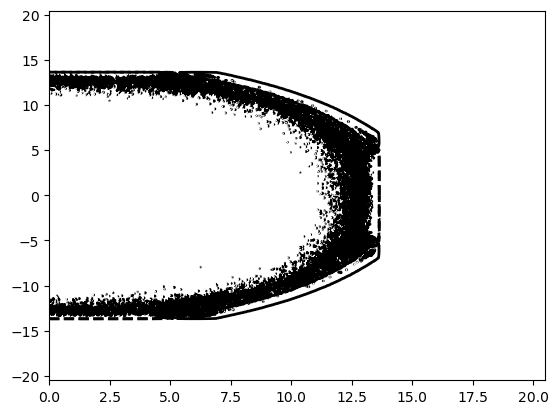

PyObject <matplotlib.contour.QuadContourSet object at 0x1452521bf5b0>

In [48]:
plt.contour(xv, yv,  a["jld_data"]["T_D"] ./ maximum(a["jld_data"]["T_D"]), colors=Bauhaus_colors[1], levels=[-0.75, -0.25, 0.25, 0.75], linewidths=2.0)


In [39]:
x = collect(range(0, 2*pi, 1024))
y = collect(range(0, 2*pi, 1024))


y1 = 2*sin.(5*2*pi*x) * (1.2 * sin.(3*2*pi*y))'
y1.+= 2*sin.(1.5*2*pi*x .- 0.2*pi) * (1.3 * cos.(7*2*pi*y))'

y2 = 1.7*sin.(4*2*pi*x .+ pi/2) * (2 * sin.(9*2*pi*y))';





In [42]:
y1h = rfft(y1)
y2h = rfft(y2)

J_y1_y2h = @. - grid.kr * y1h * grid.l * y2h + grid.l * y1h * grid.kr * y2h 

J_y1_y2 = irfft(J_y1_y2h, 1024)

println(sum(y1 .* J_y1_y2))



5.348499296241408e-36


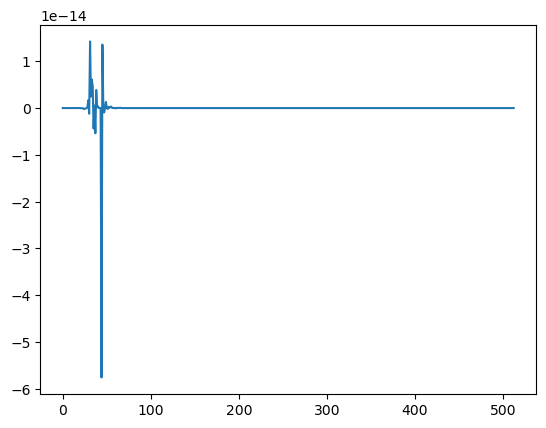

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x14d7e5912710>

In [44]:
iso_Jy = isotropic_mean(conj.(y1h) .* J_y1_y2h, grid) 

plt.plot(iso_Jy)

In [22]:
readdir(data_dir_omega)

2-element Vector{String}:
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 136 bytes ⋯ "0.000E+00_res1024_yr107.95.jld"
 "layer2_H_4000.0_L_4.449E+06_y_s" ⋯ 135 bytes ⋯ "u0.000E+00_res1024_yr54.05.jld"

# Omega decomposition


In [7]:
h0 = (0., 0.0)
kappa_loc = kappas[1]
mu_loc = mus[2]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = β = betas[10]

global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

# data_dir_omega = "/scratch/cimes/ml1994/QG/julia/data/JFM_omega_diags_data/"
data_dir_omega = "/scratch/cimes/ml1994/QG/julia/data/JFM_lp_omega_diags_data/"
data_dir_omega = "/scratch/cimes/ml1994/QG/julia/data/JFM_2D_omega_diags_data/"

a = load(data_dir_omega*jld_name(model_params,71.95))

Dict{String, Any} with 1 entry:
  "jld_data" => Dict{String, Matrix{ComplexF64}}("TW_U1z1_h"=>[0.0+0.0im -9.328…

In [14]:
w_names = [L"full", L"\nabla^2 \, J(\psi_{2}, \psi_{1})", L"J(\psi_{2}, f)", L"J(\psi_{2}, \zeta_{2})", L"J(\psi_{1}, f)",
            L"J(\psi_{1}, \zeta_{1})", L"J(U_{1}y, \zeta_{1})", L"w_{b}", L"\nabla^2 \, J(\psi_{2}, S_{3/2} y)"];

function turn_off_ax(ax; ax1_bool=false)
    if ax1_bool==true
        # Turn off the top, right, and left spines
        ax.spines["top"].set_visible(false)
        ax.spines["right"].set_visible(false)
        
        # Turn off ticks and labels for the top, right, and left axes
        ax.tick_params(top=false, right=false)
        ax.tick_params(labeltop=false, labelright=false)
    
        # Ensure the bottom axis and its labels are visible
        # ax.tick_params(bottom=true, labelbottom=true)

    else
        # Turn off the top, right, and left spines
        ax.spines["top"].set_visible(false)
        ax.spines["right"].set_visible(false)
        ax.spines["left"].set_visible(false)
        
        # Turn off ticks and labels for the top, right, and left axes
        ax.tick_params(top=false, right=false, left=false)
        ax.tick_params(labeltop=false, labelright=false, labelleft=false)
    
        # Ensure the bottom axis and its labels are visible
        ax.tick_params(bottom=true, labelbottom=true)
    end
end

turn_off_ax (generic function with 1 method)

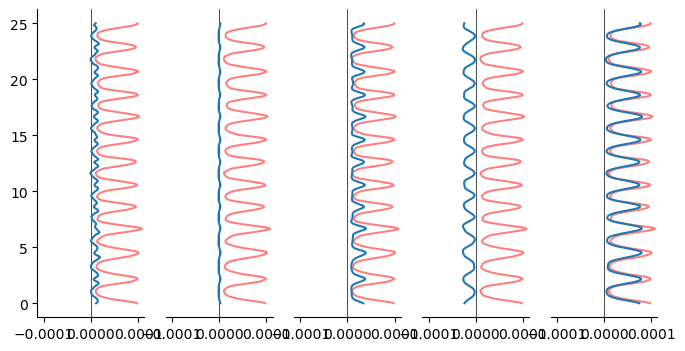

In [15]:
fig, ax = plt.subplots(1,5, figsize=(8,4))

y = collect(range(0, Lx/2/pi/Ld, Nx))

# for i in range(2,9)
#     ax.plot(a["jld_data"]["omega_diags"][:,i], y, label=w_names[i])
# end

lim = maximum(abs.(a["jld_data"]["omega_diags"][:,1])) *1.05

for axn in ax
    axn.set_xlim(-lim, lim)
    axn.plot(-a["jld_data"]["omega_diags"][:,1], y, "r-", alpha=0.5)
    # axn.plot(a["jld_data"]["omega_diags"][:,10] .* (lim / maximum(abs.(a["jld_data"]["omega_diags"][:,10]))), y, "r-", alpha=0.5)
    axn.axvline(0., color="black", linewidth=0.5, alpha=1.)
end



ax[1].plot(-a["jld_data"]["omega_diags"][:,2], y, label=L"\nabla^2 \, J(\psi_{2}, \psi_{1})")

# this one has to be in jet core because it relies on v'
ax[2].plot(-a["jld_data"]["omega_diags"][:,3] .- a["jld_data"]["omega_diags"][:,5], y, label=L"J(\tau, f)")


ax[3].plot(-a["jld_data"]["omega_diags"][:,4] .- a["jld_data"]["omega_diags"][:,6], y, label=L"J(\tau, \nabla^2 \psi)")
ax[4].plot(-a["jld_data"]["omega_diags"][:,8], y, label=L"w_\mathrm{b}")
ax[5].plot(-a["jld_data"]["omega_diags"][:,7] .- a["jld_data"]["omega_diags"][:,9], y, label=L"J(U_{1} y, \nabla^2 \psi)")

turn_off_ax(ax[1]; ax1_bool=true)
turn_off_ax(ax[2])
turn_off_ax(ax[3])
turn_off_ax(ax[4])
turn_off_ax(ax[5])
# axty = ax.twiny()



# ax.plot(sum(a["jld_data"]["omega_diags"][:,2:9], dims=2), y, "k-", linewidth=0.5)

# axty.plot(a["jld_data"]["omega_diags"][:,10], y, "r-")

########################################################################################
########################################################################################

# ax.legend()


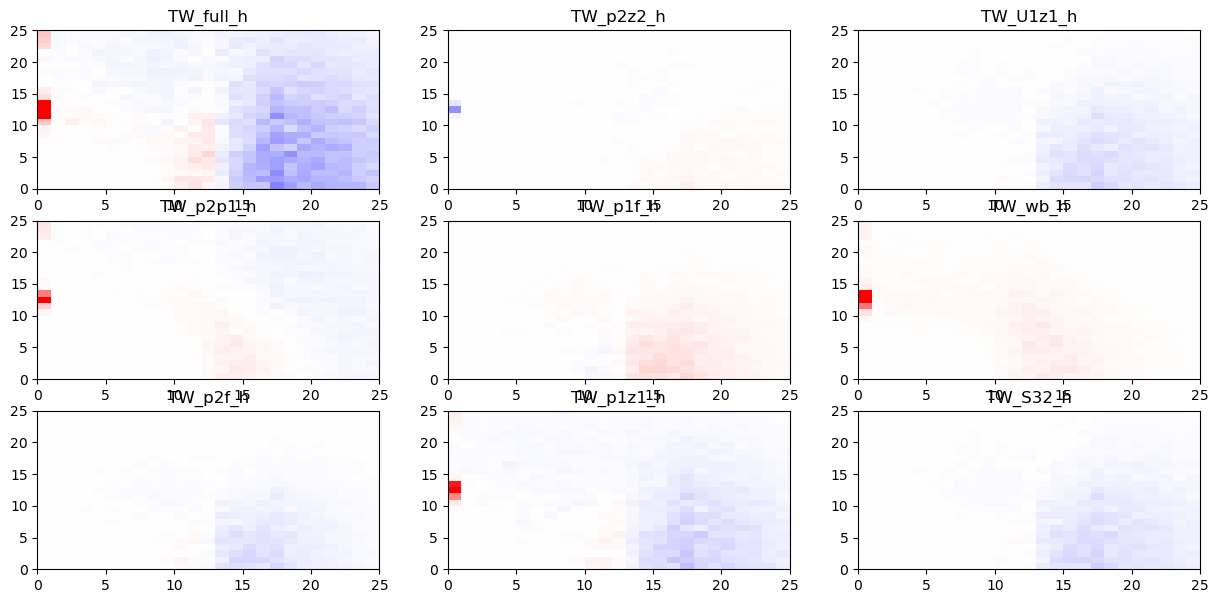

1.1085602758682434e-6

In [12]:

# "TW_full_h"]
# "TW_p2p1_h"]
# "TW_p2f_h"]
# "TW_p2z2_h"]
# "TW_p1f_h"]
# "TW_p1z1_h"]
# "TW_U1z1_h"]
# "TW_wb_h"]
# "TW_S32_h"]

TW_names= ["TW_full_h", "TW_p2p1_h", "TW_p2f_h", "TW_p2z2_h", "TW_p1f_h", "TW_p1z1_h", "TW_U1z1_h", "TW_wb_h", "TW_S32_h"]

fig, ax = plt.subplots(3,3,figsize=(15,7))

for i in range(1,9)
    lim = maximum(sqrt.(grid.Krsq) .* abs.(real.(a["jld_data"]["TW_full_h"])))/10
    ax[i].pcolormesh((sqrt.(grid.Krsq) .* real.(a["jld_data"][TW_names[i]]))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)

    ax[i].set_xlim(0,25)
    ax[i].set_ylim(0,25)

    ax[i].set_title(TW_names[i])
end

lim = maximum(sqrt.(grid.Krsq) .* abs.(real.(a["jld_data"]["TW_full_h"])))/10

# fig, ax = plt.subplots(2,3,figsize=(15,11))


# ax[1].pcolormesh((sqrt.(grid.Krsq) .* real.(a["jld_data"][names[2]]))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)
# ax[1].set_title(L"\nabla^2 \, J(\psi_{2}, \psi_{1})")

# ax[2].pcolormesh((sqrt.(grid.Krsq) .* real.(a["jld_data"][names[3]] .+ a["jld_data"][names[5]]))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)
# ax[2].set_title(L"J(\tau, f)")

# ax[3].pcolormesh((sqrt.(grid.Krsq) .* real.(a["jld_data"][names[4]] .+ a["jld_data"][names[6]]))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)
# ax[3].set_title(L"J(\tau, \nabla^2 \psi)")

# ax[4].pcolormesh((sqrt.(grid.Krsq) .* real.(a["jld_data"][names[8]]))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)
# ax[4].set_title(L"w_\mathrm{b}")

# ax[5].pcolormesh((sqrt.(grid.Krsq) .* real.(a["jld_data"][names[7]] .+ a["jld_data"][names[9]]))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)
# ax[5].set_title(L"J(U_{1} y, \nabla^2 \psi)")


# # sum_tot = zeros(size(real.(a["jld_data"][names[1]])))
# # for name in names[2:end]
# #     sum_tot .+= real.(a["jld_data"][name])
# # end

# ax[6].pcolormesh((sqrt.(grid.Krsq) .* real.(a["jld_data"][names[1]]))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)
# # ax[6].pcolormesh((sqrt.(grid.Krsq) .* (real.(a["jld_data"][names[1]]) .- sum_tot))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)

# ax[6].set_title(L"total")


# for axn in ax

#     axn.set_xlim(0,25)
#     axn.set_ylim(0,25)

# end


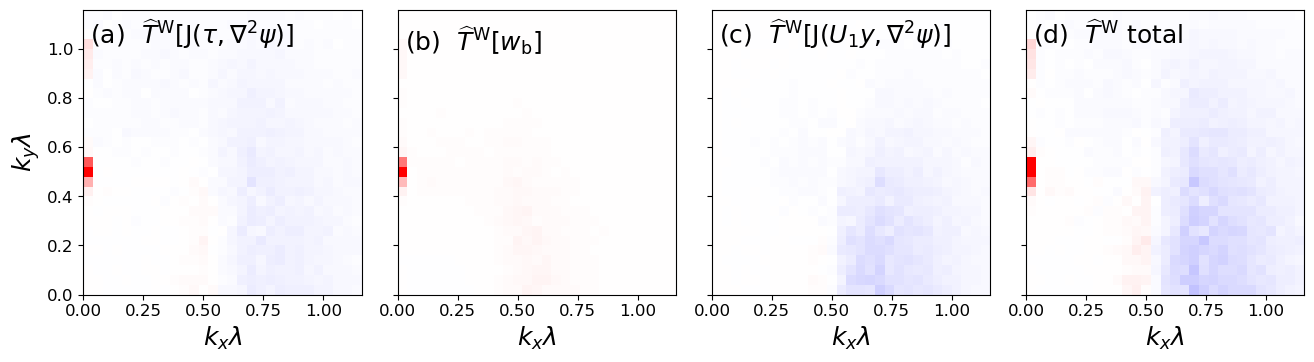

In [56]:
fig, ax = plt.subplots(1, 4, figsize=(12.5,3))

fig,tight_layout(pad=-0.5)

tsize = 20
fsize = 18
lsize = 12

x = prob.grid.kr .* Ld
y = prob.grid.l .* Ld

x = append!(x[:,1], [x[end] + x[end] - x[end-1]])
# y = append!(y[1,:], [y[end] + y[end] - y[end-1]])

y = fftshift(y)
y = append!(y[:], [20.48])

lim_range = 30

lim = maximum(sqrt.(grid.Krsq) .* abs.(real.(a["jld_data"]["TW_full_h"])))/5

# ax[1].pcolormesh((sqrt.(grid.Krsq) .* real.(a["jld_data"][names[2]]))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)
# ax[1].set_title(L"\nabla^2 \, J(\psi_{2}, \psi_{1})")

# ax[2].pcolormesh((sqrt.(grid.Krsq) .* real.(a["jld_data"][TW_names[3]] .+ a["jld_data"][TW_names[5]]))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)
# ax[2].set_title(L"J(\tau, f)")

ax[1].pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* real.(a["jld_data"][TW_names[2]] .+ a["jld_data"][TW_names[4]] .+ a["jld_data"][TW_names[6]]), 2)', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr, linewidth=0., rasterized=true)

ax[2].pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* real.(a["jld_data"][TW_names[8]]), 2)', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr, linewidth=0., rasterized=true)

ax[3].pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* real.(a["jld_data"][TW_names[7]] .+ a["jld_data"][TW_names[9]]), 2)', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr, linewidth=0., rasterized=true)


# sum_tot = zeros(size(real.(a["jld_data"][names[1]])))
# for name in names[2:end]
#     sum_tot .+= real.(a["jld_data"][name])
# end

ax[4].pcolormesh(x, y, fftshift(sqrt.(grid.Krsq) .* real.(a["jld_data"][TW_names[1]]), 2)', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr, linewidth=0., rasterized=true)
# ax[6].pcolormesh((sqrt.(grid.Krsq) .* (real.(a["jld_data"][names[1]]) .- sum_tot))', vmin=-lim, vmax=lim, cmap=PyPlot.cm.bwr)



for axn in ax
    axn.set_xlim(x[1],x[lim_range])
    axn.set_ylim(0,y[512+lim_range])
    axn.tick_params(labelsize=lsize)
    axn.set_xlabel(L"k_{x} \lambda ", fontsize=fsize)
end

for axn in ax[2:end]
    axn.set_yticklabels([])
end

ax[1].set_ylabel(L"k_{y} \lambda ", fontsize=fsize)


ax[1].text(0.025, 0.975, L"\mathrm{(a)} \ \ \widehat{T}^\mathrm{W} [ \mathrm{J}(\tau, \nabla^2 \psi) ]", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax[1].transAxes);
ax[2].text(0.025, 0.95, L"\mathrm{(b)} \ \ \widehat{T}^\mathrm{W} [ w_\mathrm{b} ]", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax[2].transAxes);
ax[3].text(0.025, 0.975, L"\mathrm{(c)} \ \ \widehat{T}^\mathrm{W} [ \mathrm{J}(U_{1} y, \nabla^2 \psi) ]", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax[3].transAxes);
ax[4].text(0.025, 0.975, L"\mathrm{(d)} \ \ \widehat{T}^\mathrm{W} \ \mathrm{total} ", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax[4].transAxes);

savefig("./JFM_BC_nrg_figs/TW_decomp.pdf",bbox_inches="tight", transparent=true)



"/scratch/cimes/ml1994/QG/julia/analysis/JFM_BC_nrg_cycles"

In [34]:
function calc_CBC_DBC_EKE(ψ)
    rfftplanlayered = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, nlayers), [1, 2]; flags=FFTW.MEASURE)
    rfftplan = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, 1), [1, 2]; flags=FFTW.MEASURE)

    # parameters
    gr = gp(rho[1:2],rho0,g) 

    Ld = sqrt(gr * sum(H)) / (2 * f0)
    # ∂yηb = topographic_pv_gradient[2] / (f0 / H[end])
    
    ψh = deepcopy(vars.ψh)

    mul!(ψh, rfftplanlayered, deepcopy(ψ))

    u = deepcopy(ψ)
    v = deepcopy(ψ)

    ldiv!(u, rfftplanlayered, -im * grid.l  .* ψh)
    ldiv!(v, rfftplanlayered, im * grid.kr  .* ψh)

    U₁, U₂, = view(params.U, :, :, 1), view(params.U, :, :, 2)
    u1, v1 = view(u, :, :, 1), view(v, :, :, 1)
    u2, v2 = view(u, :, :, 2), view(v, :, :, 2)

    ψ1, ψ2 = view(ψ, :, :, 1), view(ψ, :, :, 2)
    ψ1h, ψ2h = view(ψh, :, :, 1), view(ψh, :, :, 2)
        
    # # calculating terms used in budget
    ψ₁h, ψ₂h = view(ψh, :, :, 1), view(ψh, :, :, 2)
    
    # nonlinear terms
    ζh = -grid.Krsq .* ψh

    ζ = deepcopy(v)
    ldiv!(ζ, rfftplanlayered, -grid.Krsq .* ψh)

    ζ1, ζ2 = view(ζ, :, :, 1), view(ζ, :, :, 2)

    ∂xζ = deepcopy(ψ)
    ldiv!(∂xζ, rfftplanlayered, im .* grid.kr .* ζh)

    ∂yζ = deepcopy(ψ)
    ldiv!(∂yζ, rfftplanlayered, im .* grid.l .* ζh)

    ∂xζ1, ∂xζ2 = view(∂xζ, :, :, 1), view(∂xζ, :, :, 2)
    ∂yζ1, ∂yζ2 = view(∂yζ, :, :, 1), view(∂yζ, :, :, 2)

    ##
    J_ψ1_f = @. v1 * β
    J_ψ2_f = @. v2 * β

    J_ψ1_fh = deepcopy(ψh[:,:,1])
    mul2D!(J_ψ1_fh, rfftplan, J_ψ1_f)

    J_ψ2_fh = deepcopy(ψh[:,:,1])
    mul2D!(J_ψ2_fh, rfftplan, J_ψ2_f)

    ## J(ψ1, ζ1) & J(ψ2, ζ2)
    J_ψ1_ζ1 = @. u1 * ∂xζ1 + v1 * ∂yζ1 
    J_ψ2_ζ2 = @. u2 * ∂xζ2 + v2 * ∂yζ2

    J_ψ1_ζ1h = deepcopy(ψh[:,:,1])
    mul2D!(J_ψ1_ζ1h, rfftplan, J_ψ1_ζ1)

    J_ψ2_ζ2h = deepcopy(ψh[:,:,1])
    mul2D!(J_ψ2_ζ2h, rfftplan, J_ψ2_ζ2)

    ##
    J_ψ2_ψ1 = @. v1 * u2 - u1 * v2

    J_ψ2_ψ1h = deepcopy(ψh[:,:,1])
    mul2D!(J_ψ2_ψ1h, rfftplan, J_ψ2_ψ1)

    ∇2J_ψ2_ψ1h = - grid.Krsq .* J_ψ2_ψ1h

    ##
    v2h = im .* grid.kr .* ψ2h
    J_ψ2_S32h = v2h .* f0 .* U₁ ./ gr

    ∇2J_ψ2_S32h = - grid.Krsq .* J_ψ2_S32h

    ##
    U1_∂xζ1h = deepcopy(ψh[:,:,1])
    mul2D!(U1_∂xζ1h, rfftplan, U₁ .* ∂xζ1 )

    ##
    w_b = @. mus[2] * H[2] * ζ2 / f0

    w_bh = deepcopy(ψh[:,:,1])
    mul2D!(w_bh, rfftplan, w_b)
    
    L⁻¹ = (-grid.Krsq .- 2 * f0^2 / (gr * H[2])).^-1
    CUDA.@allowscalar L⁻¹[1,1] = 0.
    L⁻¹ = A(L⁻¹)
    
    rhs_full_h = @. - (f0/gr) * (∇2J_ψ2_ψ1h + J_ψ2_fh + J_ψ2_ζ2h - J_ψ1_fh - J_ψ1_ζ1h - U1_∂xζ1h + (f0 / H[2]) * w_bh) + ∇2J_ψ2_S32h
    
    rhs_p2p1_h = @. - (f0/gr) * ∇2J_ψ2_ψ1h
    rhs_p2f_h  = @. - (f0/gr) * J_ψ2_fh
    rhs_p2z2_h = @. - (f0/gr) * J_ψ2_ζ2h
    rhs_p1f_h  = @.   (f0/gr) * J_ψ1_fh 
    rhs_p1z1_h = @.   (f0/gr) * J_ψ1_ζ1h
    rhs_U1z1_h = @.   (f0/gr) * U1_∂xζ1h 
    rhs_wb_h   = @. - (f0/gr) * (f0 / H[2]) * w_bh
    rhs_S32_h  = ∇2J_ψ2_S32h
    
    omega_full_h = L⁻¹ .* rhs_full_h
    omega_full = deepcopy(vars.u[:,:,1])
    ldiv2D!(omega_full, rfftplan, omega_full_h)
    
    omega_p2p1_h = L⁻¹ .* rhs_p2p1_h
    omega_p2p1 = deepcopy(vars.u[:,:,1])
    ldiv2D!(omega_p2p1, rfftplan, omega_p2p1_h)
    
    omega_p2f_h = L⁻¹ .* rhs_p2f_h
    omega_p2f = deepcopy(vars.u[:,:,1])
    ldiv2D!(omega_p2f, rfftplan, omega_p2f_h)
    
    omega_p2z2_h = L⁻¹ .* rhs_p2z2_h
    omega_p2z2 = deepcopy(vars.u[:,:,1])
    ldiv2D!(omega_p2z2, rfftplan, omega_p2z2_h)
    
    omega_p1f_h = L⁻¹ .* rhs_p1f_h
    omega_p1f = deepcopy(vars.u[:,:,1])
    ldiv2D!(omega_p1f, rfftplan, omega_p1f_h)
    
    omega_p1z1_h = L⁻¹ .* rhs_p1z1_h
    omega_p1z1 = deepcopy(vars.u[:,:,1])
    ldiv2D!(omega_p1z1, rfftplan, omega_p1z1_h)
    
    omega_U1z1_h = L⁻¹ .* rhs_U1z1_h
    omega_U1z1 = deepcopy(vars.u[:,:,1])
    ldiv2D!(omega_U1z1, rfftplan, omega_U1z1_h)
    
    omega_wb_h = L⁻¹ .* rhs_wb_h
    omega_wb = deepcopy(vars.u[:,:,1])
    ldiv2D!(omega_wb, rfftplan, omega_wb_h)
    
    omega_S32_h = L⁻¹ .* rhs_S32_h
    omega_S32 = deepcopy(vars.u[:,:,1])
    ldiv2D!(omega_S32, rfftplan, omega_S32_h)
    
    kr = prob.grid.kr
    l = prob.grid.l
    Kr = @. sqrt(kr^2 + l^2)
    
    krmax = maximum(kr)
    lmax = maximum(abs.(l))
    Kmax = sqrt(krmax^2 + lmax^2)
    Kmin = 0.
    
    dkr = 2 * pi / Lx
    dl = dkr
    dKr = sqrt(dkr^2 + dl^2)
    
    K = grid.kr
    K_id = lastindex(K)
    
    j = argmin(abs.(kr .* Ld .- 2.5))
    # Define high-pass filter matrix
    lpf = ifelse.(Kr .< K[j], Kr ./ Kr, 0 .* Kr)
    lpf[1,1] = 1.0
    
    lpf = ones(size(ψ1h))
    
    # lpf[2:end-1, :] .= 0.
    
    # lpf[:,1] .= 1.0
    
    τh = 0.5 .* (ψ1h .- ψ2h)
    
    # Filter the Fourier transformed fields
    τh_lpf = τh .* lpf
    
    # Inverse transform the filtered fields
    τ_lpf = 0.5 .* (ψ1 .- ψ2) # 
    
    # τ_lpf = A(zeros(Nx, Nx))  # 
    # ldiv2D!(τ_lpf, rfftplan, deepcopy(τh_lpf))
    
    CBC = @. 0.5 * (v1 + v2) * (ψ1 .- ψ2) # τ_lpf

    DBC = @. -0.5 * ζ2 * (ψ1 - ψ2)
    
    EKE = @. (u1+u2)^2 + (v1+v2)^2
    
    return CBC, DBC, EKE
end


calc_CBC_DBC_EKE (generic function with 1 method)

In [35]:

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = β = betas[7]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
a2 = load(data_dir*jld_name_2L(model_params,71.95))
ψ = a2["jld_data"]["psi_yrs_end"]

CBC_beta0, DBC_beta0, EKE_beta0 = calc_CBC_DBC_EKE(ψ)

beta = β = betas[10]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)
a2 = load(data_dir*jld_name_2L(model_params,71.95))
ψ = a2["jld_data"]["psi_yrs_end"]

CBC_beta0p75, DBC_beta0p75, EKE_beta0p75 = calc_CBC_DBC_EKE(ψ)

######################################################################################################
######################################################################################################





([11.051933983649793 10.828942310255727 … 11.699753278459056 11.371780764537112; 13.904110782049484 13.445439832805816 … 14.553604647011332 14.30230899282456; … ; 2.705450715397544 2.6015459058892283 … 3.108744059454309 2.9038580170580324; 7.317412214275199 7.08780773919258 … 8.069104342375473 7.6900826987388005], [-8.22075889721831e-6 -7.3603634096123815e-6 … -3.0181931987001623e-5 -2.0788203523562435e-5; -2.113335467557474e-6 -5.735253392769216e-6 … -2.443747161233279e-5 -1.3073412843431457e-5; … ; -1.1260803228748183e-5 -9.408790563177395e-6 … -1.515848472747575e-5 -1.4039096882190007e-5; -1.534905144776684e-5 -1.1757779828201806e-5 … -3.152006958633438e-5 -2.5511029318242573e-5], [0.0035530310731887805 0.0034956402862487915 … 0.0036175589153827144 0.0035888914697327357; 0.0031745575331083497 0.003028294326472129 … 0.003270610396306054 0.0032550872611140707; … ; 0.004088125980116973 0.004004169429073276 … 0.004304294906671454 0.004196828457343173; 0.003897420759683295 0.003799736934

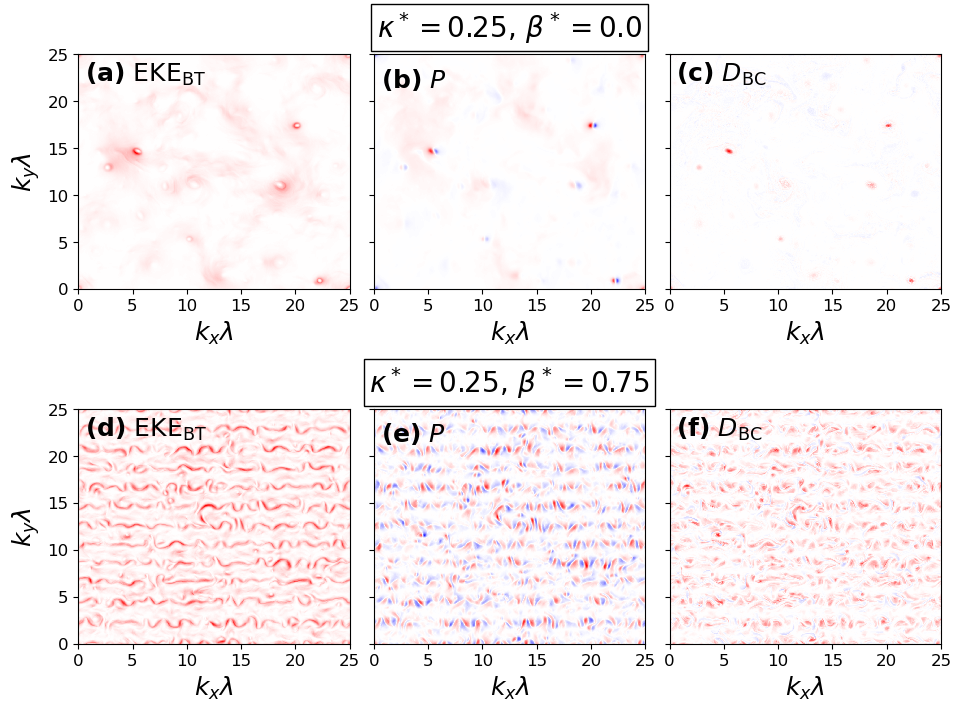

In [43]:

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = betas[7]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a = load(data_dir*jld_name_2L(model_params,71.95))


###################################################################################
###################################################################################
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subfigures.html
fig, ax = plt.subplots(3, 3, layout="constrained", figsize=(9.5, 7), height_ratios=[1., 0.005, 1.]) # , width_ratios = [1.2,1.,1.,1.])

ax1=ax[1]; ax2=ax[4]; ax3=ax[7];
ax[2].axis("off");
ax[5].axis("off");
ax[8].axis("off");
ax4=ax[3]; ax5=ax[6]; ax6=ax[9];

# clear the left column for the subfigure:
# for a in axs[:, 1]
#     a.remove()
# end

###########################################################################
############################################################################
# fig, ax = plt.subplots(1,3, figsize=(10,3))
# fig.tight_layout(pad=-2.0)

tsize = 20
fsize = 18
lsize = 12

x = y = collect(range(0, Lx / 2 / pi / Ld, 1024))

dx = dy = x[2]-x[1]

lower_x_lim = 1
upper_x_lim = 1024

lower_y_lim = 1
upper_y_lim = 1024

########################################################################################################

lim1 = maximum(EKE_beta0)

pc1 = ax1.pcolormesh(x, y, EKE_beta0', vmin=-lim1, vmax=lim1, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc1.set_edgecolor("face")

########################################################################################################

lim2 = maximum(abs.(CBC_beta0))

pc2 = ax2.pcolormesh(x, y, CBC_beta0', vmin=-lim2, vmax=lim2, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc2.set_edgecolor("face")

# ax2.contour(x, y, EKE_beta0', colors="black", levels=[0.25 * maximum(EKE_beta0)])

########################################################################################################

lim3 = maximum(abs.(DBC_beta0))

pc3 = ax3.pcolormesh(x, y, DBC_beta0', vmin=-lim3, vmax=lim3, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc3.set_edgecolor("face")

# ax3.contour(x, y, EKE_beta0', colors="black", levels=[0.25 * maximum(EKE_beta0)])

########################################################################################################

ax2.set_yticklabels([])
ax3.set_yticklabels([])


ax1.text(0.025, 0.975, L"\mathbf{(a)} \  \mathrm{EKE}_\mathrm{BT}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax1.transAxes);
ax2.text(0.025, 0.95, L"\mathbf{(b)} \ P ", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax2.transAxes);
ax3.text(0.025, 0.975, L"\mathbf{(c)} \ D_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax3.transAxes);


ax2.text(0.5, 1.115, L"\kappa^* = 0.25, \, \beta^* = 0.0", fontsize=tsize, horizontalalignment="center",verticalalignment="center", transform = ax2.transAxes,
    bbox=Dict("facecolor"=>"none", "edgecolor"=>"black"));

############################################################################
###########################################################################

beta = betas[10]


########################################################################################################

lim1 = maximum(abs.(EKE_beta0p75))

pc4 = ax4.pcolormesh(x, y, EKE_beta0p75', vmin=-lim1, vmax=lim1, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc4.set_edgecolor("face")

########################################################################################################

lim2 = maximum(abs.(CBC_beta0p75))

pc5 = ax5.pcolormesh(x, y, CBC_beta0p75', vmin=-lim2, vmax=lim2, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc5.set_edgecolor("face")

# ax5.contour(x, y, EKE_beta0p75', colors="black", levels=[0.25 * maximum(EKE_beta0p75)])

########################################################################################################

lim3 = maximum(abs.(DBC_beta0p75))

pc6 = ax6.pcolormesh(x, y, DBC_beta0p75', vmin=-lim3, vmax=lim3, cmap = PyPlot.cm.bwr, linewidth=0., rasterized=true)

pc6.set_edgecolor("face")

# ax6.contour(x, y, EKE_beta0p75', colors="black", levels=[0.25 * maximum(EKE_beta0p75)])



########################################################################################################

ax5.set_yticklabels([])
ax6.set_yticklabels([])

ax5.text(0.5, 1.115, L" \kappa^* = 0.25, \, \beta^* = 0.75", fontsize=tsize, horizontalalignment="center",verticalalignment="center", transform = ax5.transAxes,
    bbox=Dict("facecolor"=>"none", "edgecolor"=>"black"));

ax4.text(0.025, 0.975, L"\mathbf{(d)} \ \mathrm{EKE}_\mathrm{BT}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax4.transAxes);
ax5.text(0.025, 0.95, L"\mathbf{(e)} \ P ", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax5.transAxes);
ax6.text(0.025, 0.975, L"\mathbf{(f)} \ D_\mathrm{BC}", fontsize=fsize, horizontalalignment="left",verticalalignment="top", transform = ax6.transAxes);

# ax1.grid()
# ax2.grid()
# ax3.grid()





############################################################################
###########################################################################
# make the subfigure in the empty gridspec slots:



# for axn in ax[4:end]
#     axn.set_yticklabels([])
# end
# for axn in [ax[1:2]; ax[4:5]; ax[7:8]]
#     axn.set_xticklabels([])
# end

for axn in ax
    axn.tick_params(labelsize=lsize)
    axn.set_xlabel(L"k_{x} \lambda ", fontsize=fsize)

    axn.set_xlim(x[lower_x_lim], x[upper_x_lim])
    axn.set_ylim(y[lower_y_lim], y[upper_y_lim])

end

ax1.set_ylabel(L"k_{y} \lambda ", fontsize=fsize)
ax4.set_ylabel(L"k_{y} \lambda ", fontsize=fsize)

# subfig.set_facecolor('0.75')
# for ax in axsLeft:
#     pc = example_plot(ax)
# subfig.suptitle('Left plots', fontsize='x-large')
# subfig.colorbar(pc, shrink=0.6, ax=axsLeft, location='bottom')

# fig.suptitle('Figure suptitle', fontsize='xx-large')
# plt.show()


savefig("./JFM_BC_nrg_figs/2D_fields.pdf",bbox_inches="tight")



In [37]:
# # y = collect(range(0, Lx/2/pi/Ld, Nx))

# # plt.plot(TD_p1z1', y)

# # println(sum(TD_p1z1))

# plt.figure()

# plotvar = DBC# .* omega_full # DBC # τ_lpf .* omega_full # 

# println(sum(plotvar))  # -3.936745504893222e-6

# plt.pcolormesh(plotvar', vmin=-maximum(abs.(plotvar)), vmax=maximum(abs.(plotvar)), cmap=PyPlot.cm.bwr)

# plt.colorbar()

# # plt.contour(EKE', colors="black", levels=[0.25*maximum(EKE)]) 

# # plt.xlim(750, 1024)
# # plt.ylim(750, 1024)

# plt.figure()

# plotvar2 = CBC #  τ_lpf .* (∂yψBC∂xψBT .- ∂xψBC∂yψBT) # 

# plt.pcolormesh(plotvar2', vmin=-maximum(abs.(plotvar2)), vmax=maximum(abs.(plotvar2)), cmap=PyPlot.cm.bwr)
# plt.colorbar()

# # plt.contour(EKE', colors="black", levels=[0.25*maximum(EKE)]) 


# # plt.xlim(750, 1024)
# # plt.ylim(750, 1024)

-2.7841222031482623e-5


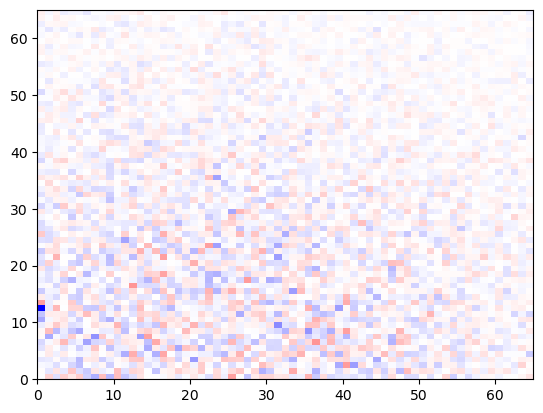

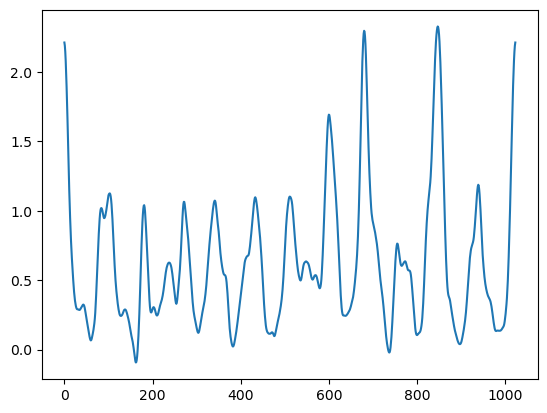

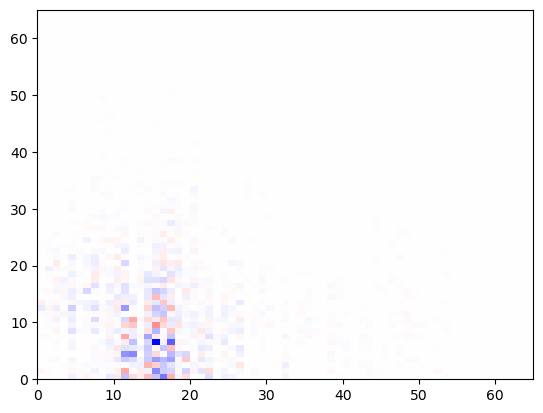

-2.7841222031482623e-5

In [21]:
pc_var = real.(rfft(plotvar .- mean(plotvar)))

plt.pcolormesh(pc_var', vmin=-maximum(abs.(pc_var)), vmax=maximum(abs.(pc_var)), cmap=PyPlot.cm.bwr)

plt.xlim(0,65)
plt.ylim(0,65)

plt.figure()
plt.plot(mean(plotvar2, dims=1)')

println(sum(pc_var))

plt.figure()

plt.pcolormesh(real.(CBCh)', vmin=-maximum(abs.(CBCh)), vmax=maximum(abs.(CBCh)), cmap=PyPlot.cm.bwr)
plt.xlim(0,65)
plt.ylim(0,65)

sum(pc_var)

In [ ]:
plt.plot(TD_full')

println(sum(TW_lpf))

println(sum(TD_full))

# plt.figure()
plt.plot(mean(TW_lpf, dims=1)')

sum(mean(TW_lpf, dims=1))

# the zonal mean is equal to: the iFFT kx=0 component of the FFT of the full field

3.556251100644727e-15
3.1086244689504383e-12 - 2.1600499167107046e-12im


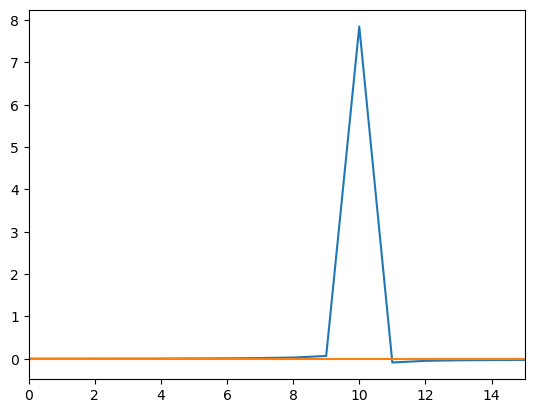

In [35]:
tt = collect(range(0,10*pi,1024))

s = sin.(tt)
c = cos.(tt)

scf = rfft(s .* c)

sch = conj.(rfft(c)) .* rfft(s)

plt.plot(real.(scf))

plt.plot(real.(sch))

plt.xlim(0,15)

println(sum(s .* c))

println(sum(ifft(sch, 1)))

In [34]:
ifft(sch,1)

513-element Vector{ComplexF64}:
 -6.160986621617016e-15 - 510.9970386740262im
     31.273986417983775 - 510.0390774027504im
      62.43066578530995 - 507.1688341649259im
      93.35322861117095 - 502.39709968420726im
     123.92574334285499 - 495.7417798210856im
     154.03359100444297 - 487.2278376882804im
     183.56389491144972 - 476.88720221745444im
     212.40594385271854 - 464.75864934381525im
     240.45160715301625 - 450.88765708371176im
      267.5957400602334 - 435.32623529182723im
     293.73657793737476 - 418.1327308306535im
     318.77611778150515 - 399.3716089259108im
      342.6204856393247 - 379.113211549779im
                        ⋮
     -342.6204856393247 - 379.113211549779im
    -318.77611778150504 - 399.37160892591083im
     -293.7365779373748 - 418.13273083065354im
    -267.59574006023325 - 435.3262352918272im
    -240.45160715301623 - 450.88765708371164im
    -212.40594385271854 - 464.7586493438152im
     -183.5638949114497 - 476.8872022174545im
      -154.03359

In [58]:

i=7
j=1
k=2


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, (0., 0.), h0)
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0(model_params, mu_loc, kappa_loc, topo_PV, h0)

beta = β = betas[10]
global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, beta)

a2 = load(data_dir*jld_name_2L(model_params,71.95))

ψ = a2["jld_data"]["psi_yrs_end"]



Dict{String, Any} with 1 entry:
  "jld_data" => Dict{String, Any}("ph_slices"=>0.0602408, "two_layer_modal_leng…

In [59]:
nlayers = Nz

dev = grid.device
T = eltype(grid)
A = device_array(dev)

rfftplanlayered = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, nlayers), [1, 2]; flags=FFTW.MEASURE)
rfftplan = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, 1), [1, 2]; flags=FFTW.MEASURE)

# parameters
gr = gp(rho[1:2],rho0,g) 

Ld = sqrt(gr * sum(H)) / (2 * f0)
# ∂yηb = topographic_pv_gradient[2] / (f0 / H[end])

ψ = a2["jld_data"]["psi_yrs_end"]

ψh = deepcopy(vars.ψh)

mul!(ψh, rfftplanlayered, deepcopy(ψ))

u = deepcopy(ψ)
v = deepcopy(ψ)

ldiv!(u, rfftplanlayered, -im * grid.l  .* ψh)
ldiv!(v, rfftplanlayered, im * grid.kr  .* ψh)

U₁, U₂, = view(params.U, :, :, 1), view(params.U, :, :, 2)
u1, v1 = view(u, :, :, 1), view(v, :, :, 1)
u2, v2 = view(u, :, :, 2), view(v, :, :, 2)

ψ1, ψ2 = view(ψ, :, :, 1), view(ψ, :, :, 2)
ψ1h, ψ2h = view(ψh, :, :, 1), view(ψh, :, :, 2)
    
# # calculating terms used in budget
ψ₁h, ψ₂h = view(ψh, :, :, 1), view(ψh, :, :, 2)

# nonlinear terms
ζh = -grid.Krsq .* ψh

ζ = deepcopy(v)
ldiv!(ζ, rfftplanlayered, -grid.Krsq .* ψh)

ζ1, ζ2 = view(ζ, :, :, 1), view(ζ, :, :, 2)

∂xζ = deepcopy(ψ)
ldiv!(∂xζ, rfftplanlayered, im .* grid.kr .* ζh)

∂yζ = deepcopy(ψ)
ldiv!(∂yζ, rfftplanlayered, im .* grid.l .* ζh)

∂xζ1, ∂xζ2 = view(∂xζ, :, :, 1), view(∂xζ, :, :, 2)
∂yζ1, ∂yζ2 = view(∂yζ, :, :, 1), view(∂yζ, :, :, 2);

In [60]:
EKE = @. 0.5 * (u1^2 + v1^2)

oth = ∂xζ1; # @. (u1 .+ U₁) * ∂xζ1;

# oth = @. ψ1 - ψ2;

#########################################################################
gr = gp(rho[1:2],rho0,g) 

##
U1_∂xζ1h = deepcopy(ψh[:,:,1])
mul2D!(U1_∂xζ1h, rfftplan, U₁ .* ∂xζ1 )
J_ψ1_ζ1 = @. u1 * ∂xζ1 + v1 * ∂yζ1 
J_ψ2_ζ2 = @. u2 * ∂xζ2 + v2 * ∂yζ2

J_ψ1_ζ1h = deepcopy(ψh[:,:,1])
mul2D!(J_ψ1_ζ1h, rfftplan, J_ψ1_ζ1)

L⁻¹ = (-grid.Krsq .- 2 * f0^2 / (gr * H[2])).^-1
L⁻¹[1,1] = 0.
L⁻¹ = A(L⁻¹)

rhs_p1z1_h = @.   (f0/gr) * J_ψ1_ζ1h
rhs_U1z1_h = @.   (f0/gr) * U1_∂xζ1h 

omega_p1z1_h = L⁻¹ .* rhs_p1z1_h
omega_p1z1 = deepcopy(vars.u[:,:,1])
ldiv2D!(omega_p1z1, rfftplan, omega_p1z1_h)

omega_U1z1_h = L⁻¹ .* rhs_U1z1_h
omega_U1z1 = deepcopy(vars.u[:,:,1])
ldiv2D!(omega_U1z1, rfftplan, omega_U1z1_h)


TD_p1z1 = (2*f0/H[2]) * (ψ[:,:,2] - ψ[:,:,1]) .* omega_p1z1

TD_U1z1 = (2*f0/H[2]) * (ψ[:,:,2] - ψ[:,:,1]) .* omega_U1z1


oth = omega_p1z1 .+ omega_U1z1;

oth = TD_p1z1 .+ TD_U1z1;

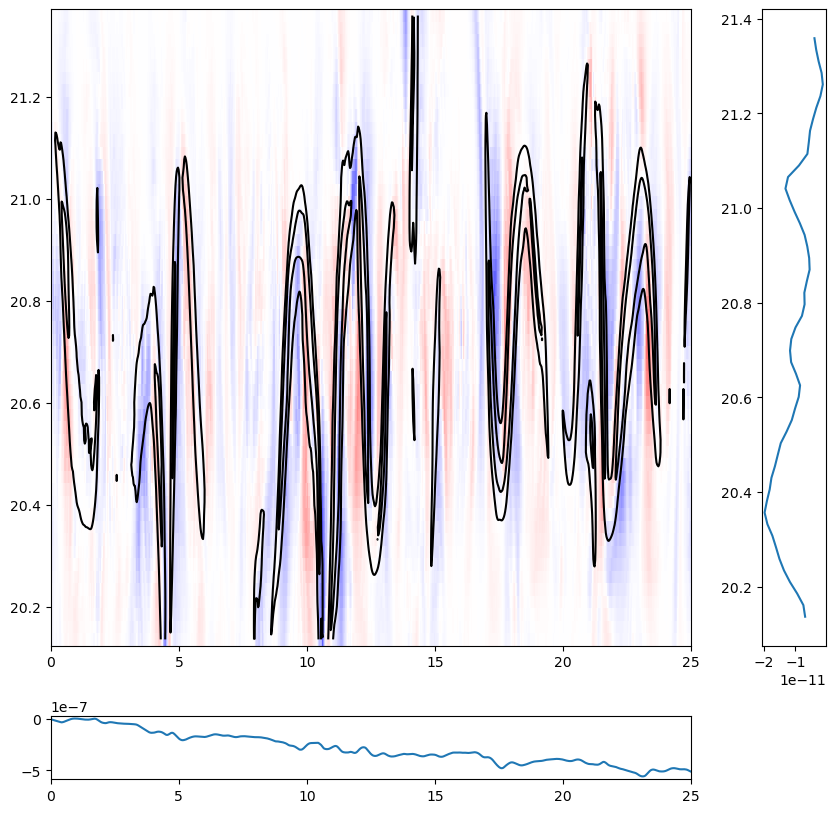

(0.0, 25.0)

In [61]:
ybottom = 825; ytop=875

fig, ax = plt.subplots(2,2, figsize=(10,10), height_ratios=[10,1], width_ratios=[10,1])
ax1=ax[1]; ax2=ax[3]; ax3=ax[2];

ax[4].axis("off")

x = y = collect(range(0, Lx/2/pi/Ld, 1024))

ax1.pcolormesh(x, y[ybottom:ytop], oth[:,ybottom:ytop]', vmin=-maximum(abs.(oth)), vmax=maximum(abs.(oth)), cmap=PyPlot.cm.bwr)

ax1.contour(x, y[ybottom:ytop], EKE[:,ybottom:ytop]', levels=[0.25 * maximum(EKE), 0.5 * maximum(EKE)], colors="black")


ax2.plot(mean(oth, dims=1)[ybottom:ytop], y[ybottom:ytop])
# ax.set_xlim(6, 11)
# ax.set_ylim(1.5, 3.5)

#############################################################################
ax3.plot(x, cumsum(sum(oth[:,ybottom:ytop], dims=2) , dims=1))

ax3.set_xlim(x[1], x[end])


In [62]:
# fig, ax = plt.subplots(1,1, figsize=(10,10))

# plt.plot(mean(oth, dims=1)[:], y)

propto_eta = @. (ψ[:,:,2] - ψ[:,:,1]) 
propto_w   = @. omega_full # omega_p1z1 + omega_U1z1

fig, ax = plt.subplots(1,1, figsize=(10,4))

# ax.plot(x, sum(propto_eta[:, ybottom:ytop], dims=2))

# axt=ax.twinx()

# axt.plot(x, sum(propto_w[:, ybottom:ytop], dims=2), "r-")

# ax3=ax.twinx()

ax.plot(x, cumsum((sum(propto_eta[:, ybottom:ytop], dims=2) .* sum(propto_w[:, ybottom:ytop], dims=2))[:]), "g-")


ax4=ax.twinx()

ax4.plot(x, (sum(propto_eta[:, ybottom:ytop], dims=2) .* sum(propto_w[:, ybottom:ytop], dims=2))[:], "k-")



LoadError: UndefVarError: `omega_full` not defined

In [63]:

fig, ax = plt.subplots(1,1, figsize=(10,4))

# ax.plot(x, sum(propto_eta[:, ybottom:ytop], dims=2))

# axt=ax.twinx()

# axt.plot(x, sum(propto_w[:, ybottom:ytop], dims=2), "r-")

# ax3=ax.twinx()

# ax.plot(x, cumsum(sum(CBC[:, ybottom:ytop], dims=2)[:]), "g-")


ax4=ax.twinx()

ax4.plot(x, -sum(CBC[:, ybottom:ytop], dims=2)[:], "k-")
ax.plot(x, (sum(propto_eta[:, ybottom:ytop], dims=2) .* sum(propto_w[:, ybottom:ytop], dims=2))[:], "r-")


LoadError: UndefVarError: `CBC` not defined

In [64]:
    nlayers = 2
    δ = [params.H[1]/sum(params.H), params.H[2]/sum(params.H)]
    g′ = g * (rho[2] -   rho[1]) / rho0 # reduced gravity at each interface
    Ld1 = (f0^2 / (g′ * params.H[1]))^-0.5
    ∂yηb = params.topographic_pv_gradient[2] / (f0 / params.H[end])
    
# assigning basic variables
ψBC = 0.5 * (ψ[:,:,1] .- ψ[:,:,2])
ψBT = 0.5 * (ψ[:,:,1] .+ ψ[:,:,2])

ψBCh = deepcopy(vars.uh[:,:,1])
ψBTh = deepcopy(vars.uh[:,:,1])

mul2D!(ψBCh, rfftplan, ψBC)
mul2D!(ψBTh, rfftplan, ψBT)

U₁, U₂, = view(params.U, :, :, 1), view(params.U, :, :, 2)

S32 = CUDA.@allowscalar f0 * U₁[1,1] / g′

# streamfunction stuff
∂xψBTh = im * grid.kr .* ψBTh
∂yψBTh = im * grid.l .* ψBTh

∂xψBT = deepcopy(vars.u[:,:,1])
∂yψBT = deepcopy(vars.u[:,:,1])

ldiv2D!(∂xψBT, rfftplan, ∂xψBTh)
ldiv2D!(∂yψBT, rfftplan, ∂yψBTh)

∂xψBCh = im * grid.kr .* ψBCh
∂yψBCh = im * grid.l .* ψBCh

∂xψBC = deepcopy(vars.u[:,:,1])
∂yψBC = deepcopy(vars.u[:,:,1])

ldiv2D!(∂xψBC, rfftplan, ∂xψBCh)
ldiv2D!(∂yψBC, rfftplan, ∂yψBCh)

# nonlinear terms
ζ = deepcopy(vars.v)
ζ[:,:,1] .= irfft(-grid.Krsq .* vars.ψh[:,:,1], grid.ny)
ζ[:,:,2] .= irfft(-grid.Krsq .* vars.ψh[:,:,2], grid.ny)
ζ₁, ζ₂ = view(ζ, :, :, 1), view(ζ, :, :, 2)

ζBCh = - grid.Krsq .* ψBCh
ζBTh = - grid.Krsq .* ψBTh

ζBC = deepcopy(vars.u[:,:,1])
ζBT = deepcopy(vars.u[:,:,1])

ldiv2D!(ζBC, rfftplan, ζBCh)
ldiv2D!(ζBT, rfftplan, ζBTh)

∂xζBCh = im * grid.kr .* ζBCh
∂xζBTh = im * grid.kr .* ζBTh

∂yζBCh = im * grid.l .* ζBCh
∂yζBTh = im * grid.l .* ζBTh

∂xζBC = deepcopy(vars.u[:,:,1])
∂xζBT = deepcopy(vars.u[:,:,1])

ldiv2D!(∂xζBC, rfftplan, ∂xζBCh)
ldiv2D!(∂xζBT, rfftplan, ∂xζBTh)

∂yζBC = deepcopy(vars.u[:,:,1])
∂yζBT = deepcopy(vars.u[:,:,1])

ldiv2D!(∂yζBC, rfftplan, ∂yζBCh)
ldiv2D!(∂yζBT, rfftplan, ∂yζBTh)

##
ζBT∂xψBTh = deepcopy(vars.uh[:,:,1])
ζBT∂yψBTh = deepcopy(vars.uh[:,:,1])

ζBC∂xψBCh = deepcopy(vars.uh[:,:,1])
ζBC∂yψBCh = deepcopy(vars.uh[:,:,1])

ζBC∂xψBTh = deepcopy(vars.uh[:,:,1])
ζBC∂yψBTh = deepcopy(vars.uh[:,:,1])

ζBT∂xψBCh = deepcopy(vars.uh[:,:,1])
ζBT∂yψBCh = deepcopy(vars.uh[:,:,1])

ψBC∂xψBTh = deepcopy(vars.uh[:,:,1])
ψBC∂yψBTh = deepcopy(vars.uh[:,:,1])


ζBT∂xψBTh = mul2D!(ζBT∂xψBTh, rfftplan, ζBT .* ∂xψBT)
ζBT∂yψBTh = mul2D!(ζBT∂yψBTh, rfftplan, ζBT .* ∂yψBT)

ζBC∂xψBCh = mul2D!(ζBC∂xψBCh, rfftplan, ζBC .* ∂xψBC)
ζBC∂yψBCh = mul2D!(ζBC∂yψBCh, rfftplan, ζBC .* ∂yψBC)

ζBC∂xψBTh = mul2D!(ζBC∂xψBTh, rfftplan, ζBC .* ∂xψBT)
ζBC∂yψBTh = mul2D!(ζBC∂yψBTh, rfftplan, ζBC .* ∂yψBT)

ζBT∂xψBCh = mul2D!(ζBT∂xψBCh, rfftplan, ζBT .* ∂xψBC)
ζBT∂yψBCh = mul2D!(ζBT∂yψBCh, rfftplan, ζBT .* ∂yψBC)

ψBC∂xψBTh = mul2D!(ψBC∂xψBTh, rfftplan, ψBC .* ∂xψBT)
ψBC∂yψBTh = mul2D!(ψBC∂yψBTh, rfftplan, ψBC .* ∂yψBT)

J_ψBT_ζBT = ∂xψBT .* ∂yζBT .- ∂yψBT .* ∂xζBT

J_ψBT_ζBTh = deepcopy(vars.uh[:,:,1])

mul2D!(J_ψBT_ζBTh, rfftplan, J_ψBT_ζBT)

ζ₁h = rfft(ζ₁)

# ζ₂h = rfft(ζ₂)

∂xζ1h = im * grid.kr .* ζ₁h 
∂xζ1 = irfft(∂xζ1h, grid.ny)

############################################################################################
BTEKE = @. 0.5 * (conj(ψBTh) * (grid.kr^2 * ψBTh) + ψBTh * conj(grid.kr^2 * ψBTh))

BCEKE = @. 0.5 * grid.kr^2 * (conj(ψBCh) * ψBCh + ψBCh * conj(ψBCh))
BCEAPE = @. 0.5 * 2 * Ld1^-2 * (conj(ψBCh) * ψBCh + ψBCh * conj(ψBCh))

############################################################################################
# Baroclinic conversion term
CBCh = @. S32 * (params.f₀ / params.H[1]) * ( conj(ψBCh) * ∂xψBTh + ψBCh * conj(∂xψBTh)) # these are equivalent!

# CBC = @. U₁ * Ld1^-2 * (conj(ψBCh) * ∂xψBTh)
# CBC .+= conj(CBC)

w_32h = calc_w_int(vars, grid, ψ, params, model_params)
T_D = @. - (f0 / H[2]) * w_32h * conj(ψBCh)
T_D .+= conj.(T_D)

############################################################################################
# Linear BC-BT flux (flat-bottom) term
BC2BT = @. 0.5 * U₁ * (conj(ψBTh) * ∂xζBCh + ψBTh * conj(∂xζBCh))

############################################################################################
# Nonlinear terms in BT budget
NLBT = zeros(dev, T, (grid.nkr,grid.ny,2)) .+ 0im
@views NLBT[:,:,1] = @. conj(ψBTh) * J_ψBT_ζBTh + ψBTh * conj(J_ψBT_ζBTh)  # im * (grid.l * ζBT∂xψBTh - grid.kr * ζBT∂yψBTh)
# NLBT[:,:,1] .+= conj.(NLBT[:,:,1])

@views NLBT[:,:,2] = @. conj(ψBTh) * im * (grid.l * ζBC∂xψBCh - grid.kr * ζBC∂yψBCh)
@views NLBT[:,:,2] .+= conj.(NLBT[:,:,2])

############################################################################################
# Nonlinear terms in BC budget
NLBC = zeros(dev, T, (grid.nkr,grid.ny,3)) .+ 0im

#NLBC2BT
@views NLBC[:,:,1] = @. conj(ψBCh) * im * (grid.l * ζBC∂xψBTh - grid.kr * ζBC∂yψBTh)
@views NLBC[:,:,1] .+= conj.(NLBC[:,:,1])

#NLBCEKE
@views NLBC[:,:,2] = @. conj(ψBCh) * im * (grid.l * ζBT∂xψBCh - grid.kr * ζBT∂yψBCh)
@views NLBC[:,:,2] .+= conj.(NLBC[:,:,2])

#NLBCEAPE
@views NLBC[:,:,3] = @. - 2 * Ld1^-2 * conj(ψBCh) * im * (grid.l * ψBC∂xψBTh - grid.kr * ψBC∂yψBTh)
@views NLBC[:,:,3] .+= conj.(NLBC[:,:,3])

513×1024 view(::Array{ComplexF64, 3}, :, :, 3) with eltype ComplexF64:
          0.0+0.0im    0.00155442+0.0im  …    0.00155442+0.0im
  -3.04989e-6+0.0im   0.000103853+0.0im      0.000183738+0.0im
  0.000373907+0.0im  -0.000519661+0.0im      0.000624112+0.0im
 -0.000475886+0.0im  -0.000165482+0.0im        5.5717e-5+0.0im
   0.00108238+0.0im   0.000270459+0.0im     -0.000282155+0.0im
   -0.0014757+0.0im    0.00151178+0.0im  …   0.000899948+0.0im
  0.000853061+0.0im   0.000307534+0.0im     -0.000739906+0.0im
   0.00213236+0.0im    0.00105265+0.0im       0.00098182+0.0im
  -0.00112457+0.0im   -6.02049e-5+0.0im      0.000253291+0.0im
 -0.000121529+0.0im   0.000768295+0.0im     -0.000367092+0.0im
  0.000453169+0.0im   -0.00048788+0.0im  …   -0.00444719+0.0im
   1.52192e-5+0.0im   -0.00484024+0.0im      -0.00523402+0.0im
  0.000517022+0.0im   -0.00113771+0.0im       0.00863455+0.0im
             ⋮                           ⋱  
  6.13392e-25+0.0im  -3.11526e-24+0.0im     -2.50548e-24+0.0im
  

In [65]:
# ψBC∂xψBTh = mul2D!(ψBC∂xψBTh, rfftplan, ψBC .* ∂xψBT)
# ψBC∂yψBTh = mul2D!(ψBC∂yψBTh, rfftplan, ψBC .* ∂yψBT)

∂yψBC∂xψBT = deepcopy(vars.u[:,:,1])
∂xψBC∂yψBT = deepcopy(vars.u[:,:,1])

ldiv2D!(∂yψBC∂xψBT, rfftplan, im .* grid.l .* ψBC∂xψBTh )
ldiv2D!(∂xψBC∂yψBT, rfftplan, im .* grid.kr .* ψBC∂yψBTh )


# (grid.l * ψBC∂xψBTh - grid.kr * ψBC∂yψBTh)

1024×1024 Matrix{Float64}:
  2.11871e-5   2.37629e-5    1.79216e-5   …   1.36913e-5   1.50106e-5
 -7.15245e-6  -1.9447e-5    -2.45544e-5       2.06859e-5   5.02049e-6
 -3.4386e-5   -5.69883e-5   -6.23153e-5       8.51589e-6  -1.19206e-5
 -2.34081e-5  -5.45186e-5   -7.93242e-5       1.07397e-5  -1.4579e-6
 -5.44675e-5  -7.45721e-5   -8.21274e-5       3.67037e-6  -2.40193e-5
 -8.08377e-5  -8.51545e-5   -6.94172e-5   …  -4.02899e-5  -6.06003e-5
 -2.39051e-5  -3.7698e-5    -5.9578e-5       -4.84174e-5  -3.23697e-5
 -5.92669e-6  -2.85318e-5   -7.24344e-5      -9.76755e-6  -9.12336e-6
 -4.79084e-5  -7.56756e-5   -8.99765e-5       1.50412e-5  -1.51664e-5
 -3.05745e-5  -8.27716e-5   -0.000105996      3.0428e-5    1.8106e-5
 -1.63996e-6  -4.27556e-5   -9.8046e-5    …   4.38659e-5   2.93486e-5
 -6.73584e-6   5.99825e-6   -3.47247e-5       4.70877e-5   1.31181e-6
  1.86352e-5   2.33473e-5    6.71001e-7       5.28041e-5   3.05869e-5
  ⋮                                       ⋱               
  5.32